# **Практикум на ЭВМ**

*Морозова Софья Васильевна, 316*

**Описание датасета**

Датасет представляет собой набор финансовых критериев, касающихся кредитов. Кредитный рейтинг может быть одним из трех типов: хороший, стандартный, плохой.

1. Occupation — Род занятий потребителя
2. Annual_Income — Годовой доход
3. Monthly_Inhand_Salary — Ежемесячная зарплата
4. Num_Bank_Accounts — Количество банковских счетов
5. Num_Credit_Card — Количество кредитных карт
6. Interest_Rate — Процентная ставка
7. Num_of_Loan — Количество кредитов
8. Delay_from_due_date — Отложенный срок выполнения
9. Num_of_Delayed_Payment — Количество просроченных платежей
10. Changed_Credit_Limit — Изменен кредитный лимит
11. Num_Credit_Inquiries — Количество запросов по кредитам
12. Credit_Mix — Структура кредитов
13. Outstanding_Debt — Непогашенная задолженность
14. Credit_Utilization_Ratio — Коэффициент использования кредита
15. Credit_History_Age — Возраст кредитной истории
16. Payment_of_Min_Amount — Минимальная сумма платежа
17. Total_EMI_per_month — Общий объем инвестиций в месяц
18. Amount_invested_monthly — Сумма ежемесячных инвестиций
19. Payment_Behaviour — Порядок осуществления платежей
20. Monthly_Balance — Баланс за месяц
21. Customer_ID — Айдишник потребителя
22. Age — Возраст потребителя

Подключаем к окружению датасет и нужные библиотеки:

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, spearmanr, kendalltau
import seaborn as sns

In [2]:
df = pd.read_csv('Credit_score_cleaned_data.csv')
df

,Customer_ID,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Last_Loan_9,Last_Loan_8,Last_Loan_7,Last_Loan_6,Last_Loan_5,Last_Loan_4,Last_Loan_3,Last_Loan_2,Last_Loan_1,Credit_Score
0,CUS_0x98ed,31,Journalist,22229.060,1672.421667,6,4,5.0,3,10,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Debt Consolidation Loan,Standard
1,CUS_0x36b4,43,Musician,17060.705,1685.725417,8,3,11.0,4,24,...,No Loan,No Loan,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Auto Loan,Auto Loan,Standard
2,CUS_0x105b,24,Accountant,34428.210,2575.017500,2,4,8.0,0,3,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Good
3,CUS_0x4c4a,21,Accountant,12613.920,1155.160000,4,6,13.0,3,14,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Personal Loan,Student Loan,Home Equity Loan,Standard
4,CUS_0x612f,31,Journalist,34775.160,3048.930000,7,9,25.0,5,20,...,No Loan,No Loan,No Loan,No Loan,Auto Loan,Mortgage Loan,Auto Loan,Payday Loan,Not Specified,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0xc52a,46,Writer,35032.660,2853.388333,10,6,33.0,7,48,...,No Loan,No Loan,Credit-Builder Loan,Student Loan,Personal Loan,Mortgage Loan,Payday Loan,Payday Loan,Student Loan,Poor
99996,CUS_0x83cc,34,Engineer,125047.240,10682.603333,2,5,9.0,0,11,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Standard
99997,CUS_0x6ae6,26,Lawyer,9045.485,644.664842,8,7,20.0,6,52,...,No Loan,No Loan,No Loan,Not Specified,Student Loan,Auto Loan,Not Specified,Student Loan,Auto Loan,Poor
99998,CUS_0x6f0c,20,Lawyer,53564.880,4207.740000,5,3,13.0,2,6,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Mortgage Loan,Personal Loan,Standard


# 1. Описание, краткие характеристики (максимумы-минимумы, средние значения, пропуски и т.д.)

In [5]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,33.309240,50505.123449,4198.771859,5.368800,5.533640,14.53208,3.532880,21.068780,13.329240,10.389098,5.772820,1426.220376,32.285173,221.206880,88.209450,193.686347,403.492393
std,10.764996,38299.422093,3187.494345,2.593279,2.067073,8.74133,2.446356,14.860104,6.269066,6.783550,3.861137,1155.129026,5.116875,99.681112,83.244703,194.785222,214.423009
min,14.000000,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,-5.000000,0.000000,-6.490000,0.000000,0.230000,20.000000,1.000000,-1.000000,0.000000,0.007760
25%,24.000000,19342.972500,1626.761667,3.000000,4.000000,7.00000,2.000000,10.000000,9.000000,5.340000,3.000000,566.072500,28.052567,144.000000,25.589532,73.730625,270.322511
50%,33.000000,36999.705000,3096.378333,5.000000,5.000000,13.00000,3.000000,18.000000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,61.541296,129.361839,337.270985
75%,42.000000,71683.470000,5961.745000,7.000000,7.000000,20.00000,5.000000,28.000000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,131.528154,234.346249,471.928804
max,56.000000,179987.280000,15204.633333,11.000000,11.000000,34.00000,9.000000,67.000000,28.000000,36.970000,17.000000,4998.070000,50.000000,404.000000,357.406068,1977.326102,1602.040519


In [6]:
df.isna().sum()

Customer_ID                 0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Last_Loan_9                 0
Last_Loan_8                 0
Last_Loan_7                 0
Last_Loan_6                 0
Last_Loan_5                 0
Last_Loan_4                 0
Last_Loan_3                 0
Last_Loan_2                 0
Last_Loan_1                 0
Credit_Score                0
dtype: int64

**Важно отметить, что пропусков в данных нет.**

# 2. Реализовать аппроксимацию распределений данных с помощью ядерных оценок.

KDE — это метод аппроксимации функции плотности вероятности случайной величины с использованием конечной выборки. Он не предполагает конкретного распределения данных, а оценивает форму распределения непосредственно по точкам данных. Также KDE сглаживает гистограмму, которая покаазывает, как распределены данные.

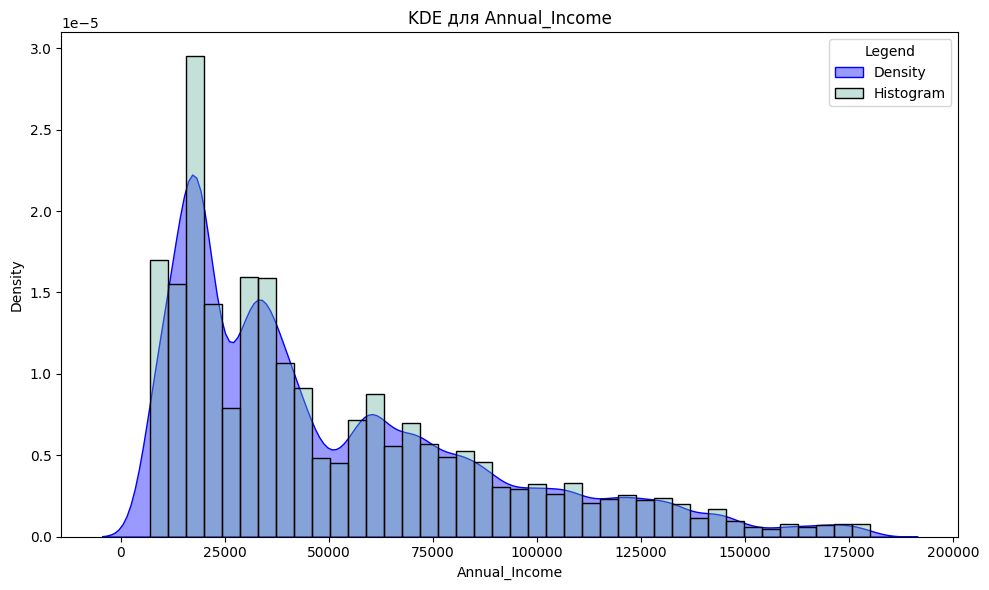

In [7]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Annual_Income'], 
            fill=True, 
            alpha=0.4, 
            linewidth=1, 
            color='blue', 
            label='Density')
sns.histplot(df['Annual_Income'], 
             bins=40, 
             stat='density', 
             color='#69b3a2', 
             alpha=0.4, 
             edgecolor='black', 
             label='Histogram')
plt.legend(title='Legend', loc='upper right')
plt.title('KDE для Annual_Income')
plt.tight_layout()
plt.show()

Несколько выводов:
1. Логнормальное распределение совпадает с хвостом распределения для Annual_Income.
2. Выраженные выбросы отсутствуют.
3. Метод сглаживания корректен, так как плотность, отображаемая KDE, согласуется с гистограммой.

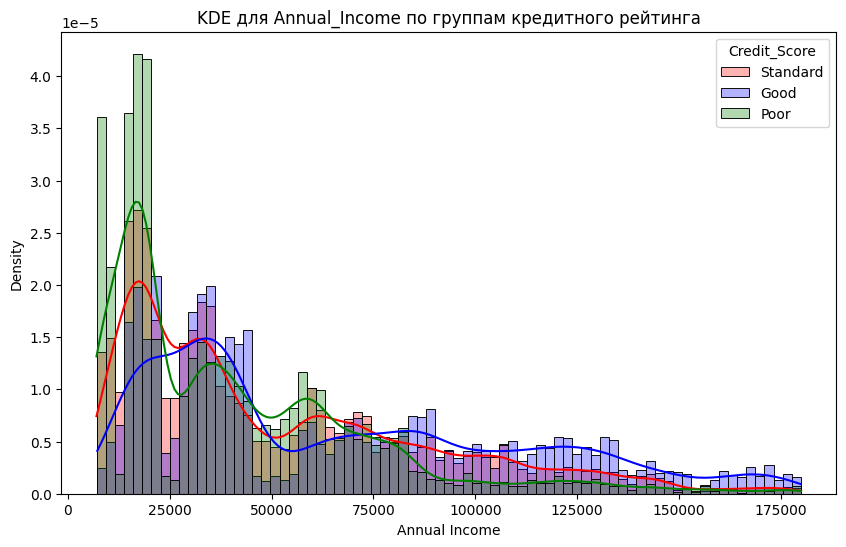

In [8]:
plt.figure(figsize=(10,6))

edges = np.histogram_bin_edges(df['Annual_Income'], bins='fd')

for credit_mix, color in zip(df['Credit_Score'].unique(), ['red', 'blue', 'green']):
    sns.histplot(
        data=df[df['Credit_Score'] == credit_mix]['Annual_Income'],
        stat='density',
        kde=True,
        bins=edges,
        color=color,
        alpha=0.3,
        label=credit_mix
    )

plt.xlabel("Annual Income")
plt.ylabel("Density")
plt.title("KDE для Annual_Income по группам кредитного рейтинга")
plt.legend(title="Credit_Score")
plt.show()

Здесь каждая кривая соответсвует группе по Credit_Score. Также наблюдается зависимость дохода от кредитного рейтинга (чем выше доход — тем выше вероятность хорошего рейтинга).

# 3. Реализовать анализ данных с помощью cdplot, dotchart, boxplot и stripchart.

1) cdplot показывает вероятность принадлежности к опеределенной категории в зависимости от значения признака (числовой переменной).
В данном случае, категориальная переменная — Credit_Score, а числовая — Monthly_Inhand_Salary.

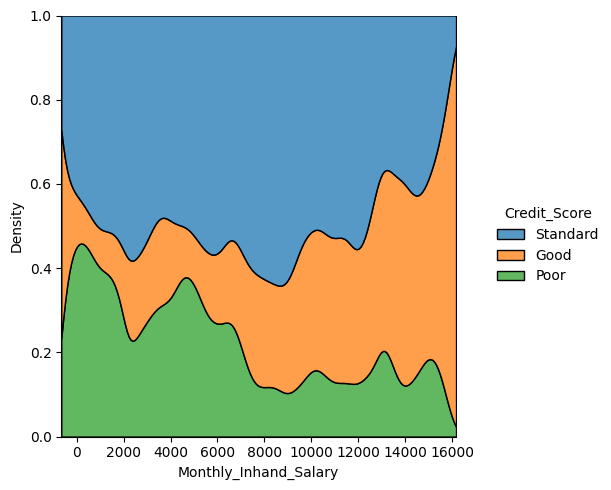

In [39]:
sns.displot(data = df, hue = "Credit_Score", multiple = "fill", x = "Monthly_Inhand_Salary", kind = "kde");

2) dotchart отображает значения количественного признака по кагероиям в виде точек.
Для анализа были выбраны переменные Num_of_Loan и Credit_Utilization_Ratio

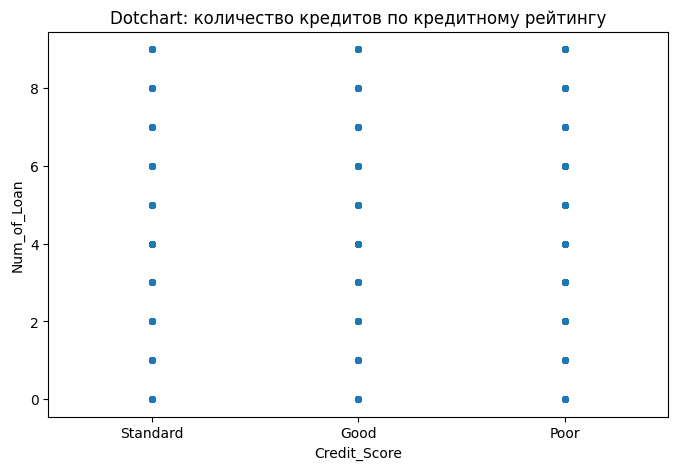

In [62]:
plt.figure(figsize=(8,5))
sns.stripplot(data=df, x="Credit_Score", y="Num_of_Loan", jitter=False)
plt.title("Dotchart: количество кредитов по кредитному рейтингу")
plt.show()

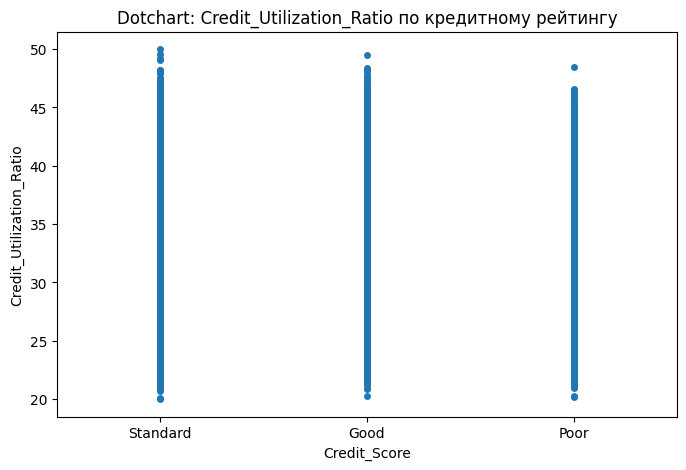

In [9]:
plt.figure(figsize=(8,5))
sns.stripplot(data=df, x="Credit_Score", y="Credit_Utilization_Ratio", jitter=False)
plt.title("Dotchart: Credit_Utilization_Ratio по кредитному рейтингу")
plt.show()

Видно, что кредитный рейтинг ухудшается из-за высокого Credit_Utilization_Ratio.

3) boxplot (или же "ящик с усами") показывает, где сосредоточена основная масса данных, насколько сильно они разбросаны, также позволяет понять, есть ли выбросы (значения, выходящие за "усы").

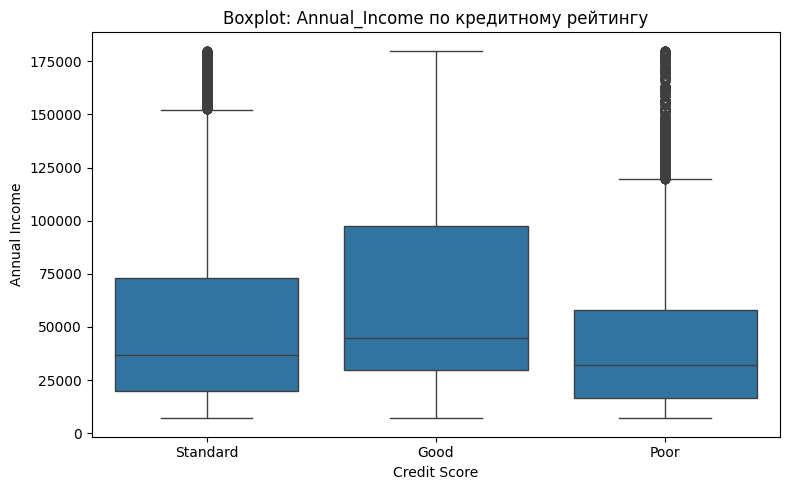

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Credit_Score", y="Annual_Income")
plt.title("Boxplot: Annual_Income по кредитному рейтингу")
plt.xlabel("Credit Score")
plt.ylabel("Annual Income")
plt.tight_layout()
plt.show()

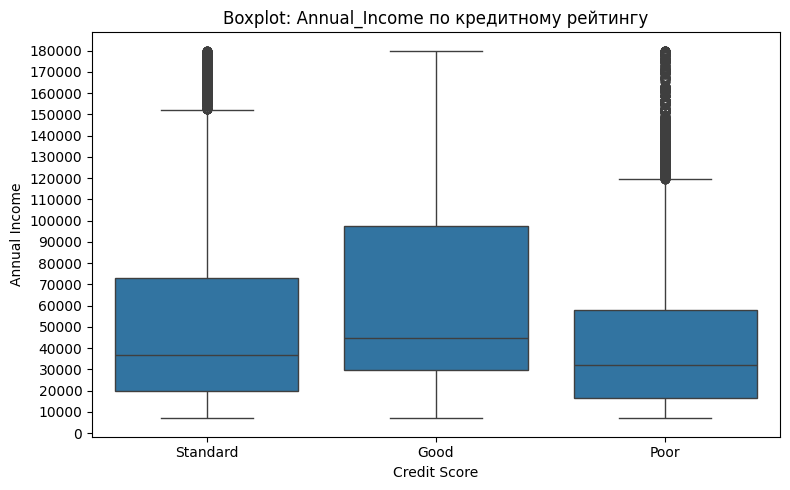

In [65]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Credit_Score", y="Annual_Income")

plt.yticks(np.arange(0, 180001, 10000))

plt.title("Boxplot: Annual_Income по кредитному рейтингу")
plt.xlabel("Credit Score")
plt.ylabel("Annual Income")
plt.tight_layout()
plt.show()

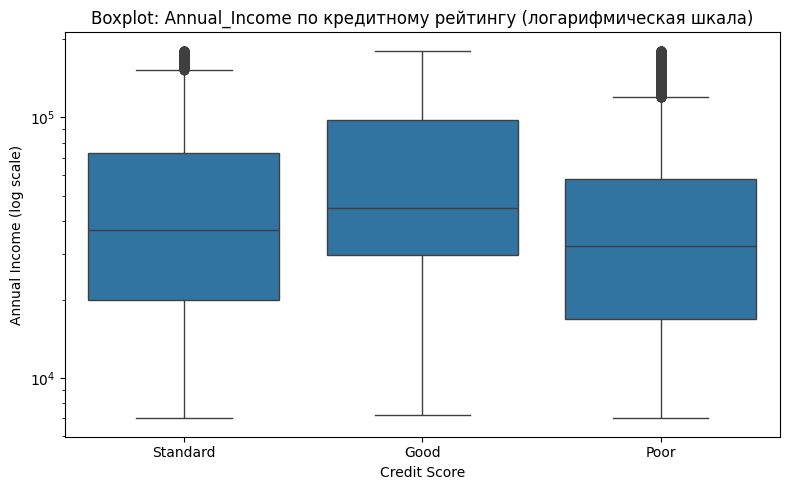

In [66]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Credit_Score", y="Annual_Income")
plt.yscale("log")
plt.title("Boxplot: Annual_Income по кредитному рейтингу (логарифмическая шкала)")
plt.xlabel("Credit Score")
plt.ylabel("Annual Income (log scale)")
plt.tight_layout()
plt.show()

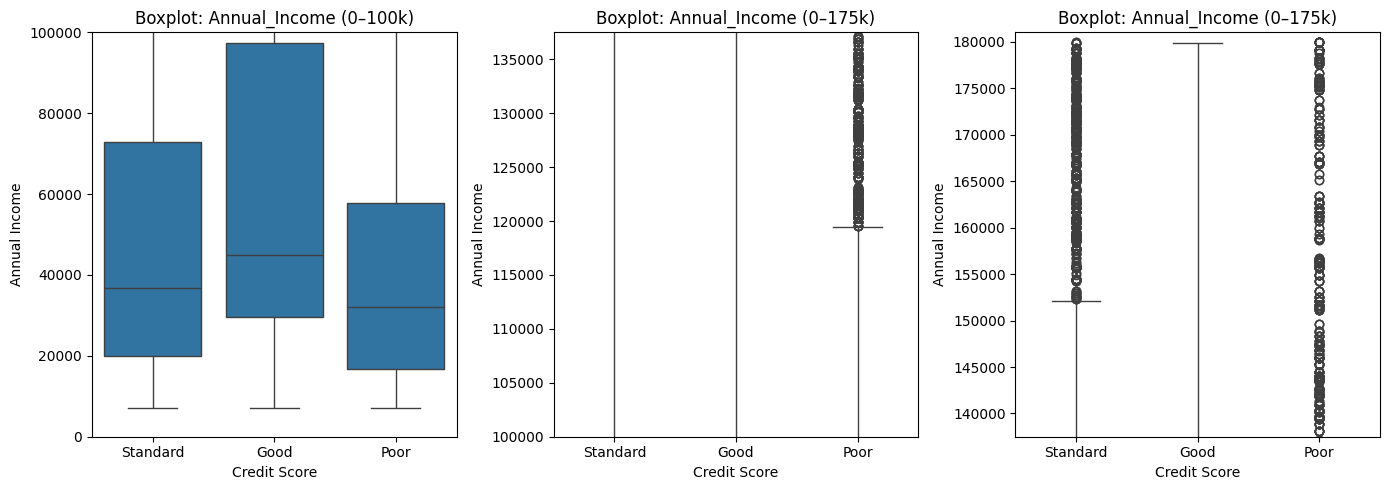

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(14,5), sharex=True)

sns.boxplot(data=df, x="Credit_Score", y="Annual_Income", ax=axes[0])
axes[0].set_ylim(0, 100000)
axes[0].set_title("Boxplot: Annual_Income (0–100k)")
axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Annual Income")

sns.boxplot(data=df, x="Credit_Score", y="Annual_Income", ax=axes[1])
axes[1].set_ylim(100000, 137500)
axes[1].set_title("Boxplot: Annual_Income (0–175k)")
axes[1].set_xlabel("Credit Score")
axes[1].set_ylabel("Annual Income")

sns.boxplot(data=df, x="Credit_Score", y="Annual_Income", ax=axes[2])
axes[2].set_ylim(137500, 181000)
axes[2].set_title("Boxplot: Annual_Income (0–175k)")
axes[2].set_xlabel("Credit Score")
axes[2].set_ylabel("Annual Income")

plt.tight_layout()
plt.show()

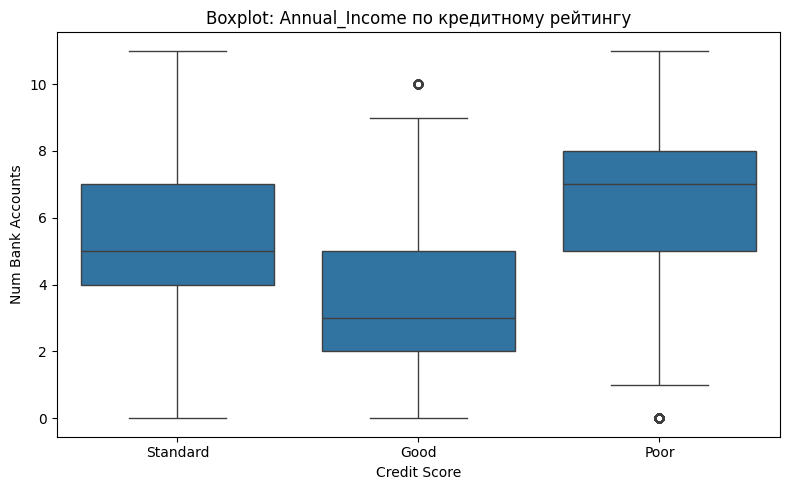

In [68]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Credit_Score", y="Num_Bank_Accounts")
plt.title("Boxplot: Annual_Income по кредитному рейтингу")
plt.xlabel("Credit Score")
plt.ylabel("Num Bank Accounts")
plt.tight_layout()
plt.show()

4) stripplot похож на dotchart, но добавляет смещение (засчет jitter=True), чтобы точки не накладывались друг на друга.
Возьмем топ-5 профессий и посмотрим на плонтость точек ждя них.

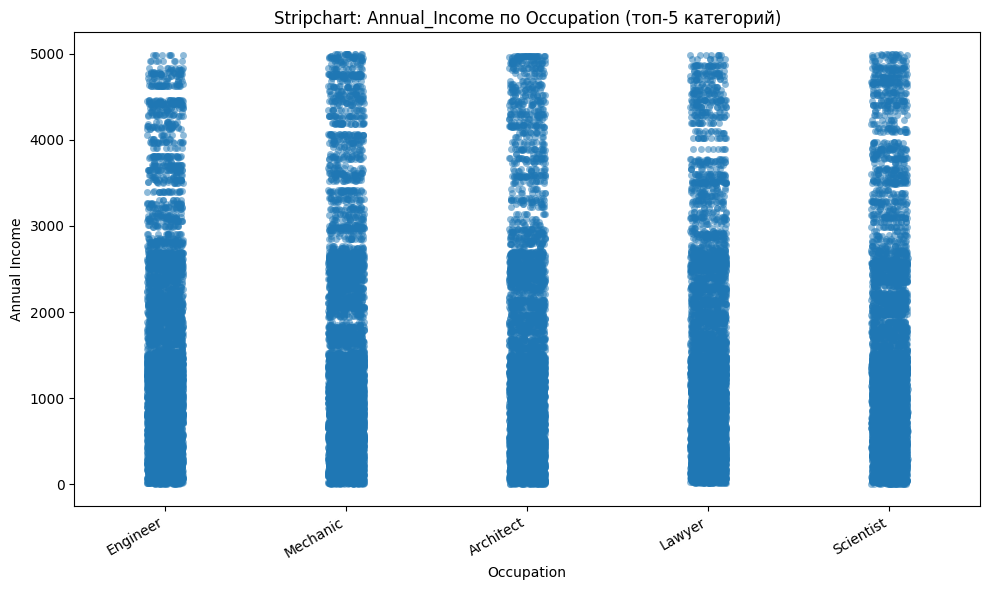

In [69]:
top5_occ = df['Occupation'].value_counts().nlargest(5).index
df_top5 = df[df['Occupation'].isin(top5_occ)]

plt.figure(figsize=(10,6))
sns.stripplot(data=df_top5, x="Occupation", y="Outstanding_Debt", jitter=True, alpha=0.5)
plt.title("Stripchart: Annual_Income по Occupation (топ-5 категорий)")
plt.xlabel("Occupation")
plt.ylabel("Annual Income")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# 5. Воспользоваться инструментами для заполнения пропусков в данных. Пропуски внести вручную и сравнить результаты заполнения с истинными значениями. 

Сначала посмотрим на KDE без пропусков, чтобы потом сравнить с KDE с пропусками, и оценить, насколько близкие результаты получаются с помощью заполнения пропусков разными способами.

In [3]:
df = pd.read_csv('Credit_score_cleaned_data.csv')

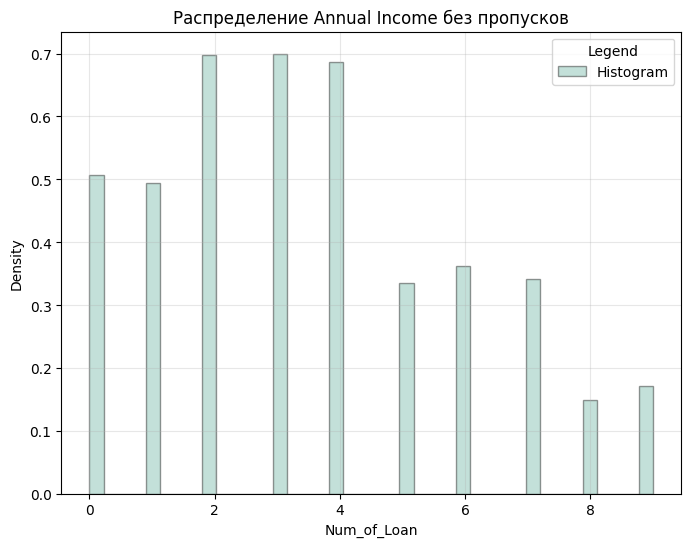

In [4]:
def hist_income(replace):
    plt.figure(figsize=(8, 6))
    plt.hist(df['Num_of_Loan'], bins=40, density=True, color='#69b3a2', alpha=0.4, edgecolor='black')
    plt.legend(['Histogram'], loc='upper right', title="Legend", fontsize=10)
    plt.title(f"Распределение Annual Income {replace}")
    plt.xlabel('Num_of_Loan')
    plt.ylabel('Density')
    plt.grid(alpha=0.3)
    plt.show()

hist_income('без пропусков')

Внесем пропуски вручную. Я решила внести 2000 пропусков, так как данных в датасете довольно много, и на KDE малое их количество никак не отражается даже после заполнения.

In [5]:
import random
indices = random.sample(range(1, 9998), 2000)
print(df['Num_of_Loan'][indices[:20]])

9924    7
5088    2
4309    6
3906    3
3194    3
5182    2
4302    2
842     4
3721    0
9805    7
1422    3
1394    7
1142    4
485     2
1399    0
3163    1
7194    7
2688    9
7493    0
3770    2
Name: Num_of_Loan, dtype: int64


In [6]:
print('median: ', df['Num_of_Loan'].median())
print('mean:   ', df['Num_of_Loan'].mean())

median:  3.0
mean:    3.53288


In [7]:
df.loc[indices, 'Num_of_Loan'] = np.nan

Проверяем, удалились ли данные.

In [8]:
sum(df['Num_of_Loan'].isna())

2000

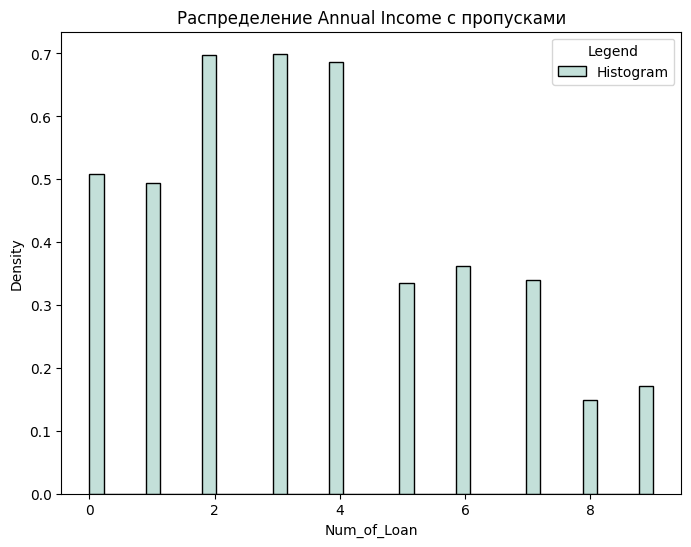

In [10]:
def hist_income(replace):
    plt.figure(figsize=(8, 6))
    sns.histplot(df['Num_of_Loan'], bins=40, stat='density', color='#69b3a2', alpha=0.4, edgecolor='black')
    plt.legend(['Histogram'], loc='upper right', title="Legend", fontsize=10)
    plt.title(f"Распределение Annual Income {replace}")
    plt.xlabel('Num_of_Loan')
    plt.ylabel('Density')
    plt.show()

hist_income('с пропусками')

Как видим, KDE с пропусками не поменялась (даже с 2000).

In [11]:
med = df['Num_of_Loan'].median()
df.loc[indices, 'Num_of_Loan'] = med
print(med)

3.0


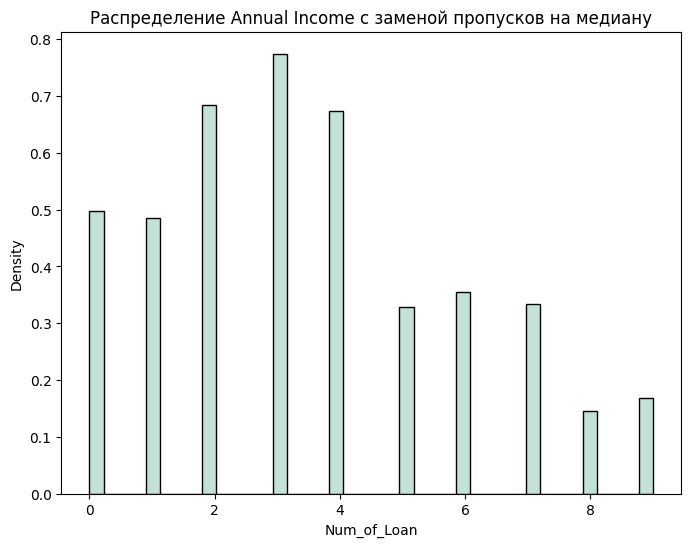

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_filled = df.copy()
df_filled['Num_of_Loan'] = df_filled['Num_of_Loan'].fillna(df_filled['Num_of_Loan'].median())

def hist_income(replace):
    plt.figure(figsize=(8, 6))
    sns.histplot(df_filled['Num_of_Loan'], bins=40, stat='density', color='#69b3a2', alpha=0.4, edgecolor='black')
    plt.title(f"Распределение Annual Income {replace}")
    plt.xlabel('Num_of_Loan')
    plt.ylabel('Density')
    plt.show()

hist_income('с заменой пропусков на медиану')

In [13]:
mean = df['Num_of_Loan'].mean()
df.loc[indices, 'Num_of_LOan'] = mean
print(mean)

3.52088


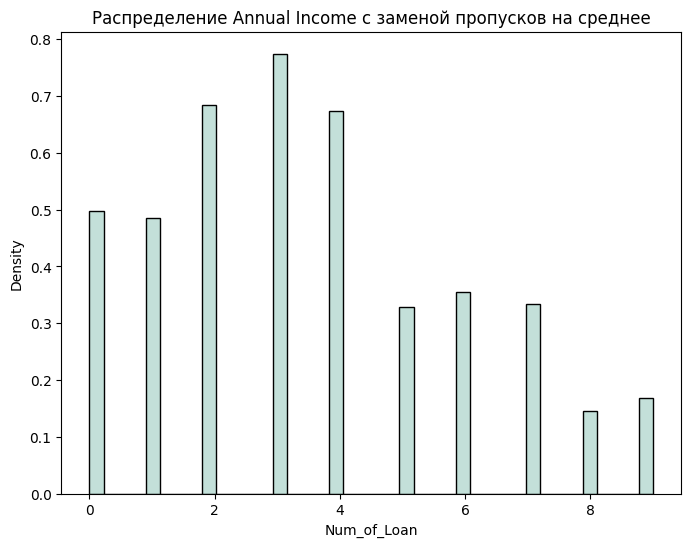

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_filled = df.copy()
df_filled['Num_of_Loan'] = df_filled['Num_of_Loan'].fillna(df_filled['Num_of_Loan'].mean())

def hist_income(replace):
    plt.figure(figsize=(8, 6))
    sns.histplot(df_filled['Num_of_Loan'], bins=40, stat='density', color='#69b3a2', alpha=0.4, edgecolor='black')
    plt.title(f"Распределение Annual Income {replace}")
    plt.xlabel('Num_of_Loan')
    plt.ylabel('Density')
    plt.show()

hist_income('с заменой пропусков на среднее')

Методы заполснения пропусков с помощью медианы и среднего близки к реальным. Есть выраженная разница только в серединных значениях.

# 6. Анализ данных из нормального распределения.

Сгенерируем выборки малого, среднего и большого размера.

In [5]:
dt1 = np.random.normal(loc=0, scale=1, size=50)
dt2 = np.random.normal(loc=2, scale=2, size=100)
dt3 = np.random.normal(loc=1, scale=4, size=5000)
dt4 = np.random.normal(loc=11, scale=3, size=2000)
dt5 = np.random.normal(loc=1, scale=1, size=1000)

**1. Анализ данных с помощью графиков эмпирических функций распределения.**

In [6]:
from scipy.stats import norm
def f(data, color, text):
    sns.displot(data = data, kind = "ecdf", color = color, label='Эмпирическая функция распределения').set(title='Эмпирическая функция распределения ' + text)
    x = np.linspace(min(data), max(data), 1000)
    y = norm.cdf(x, loc=np.mean(data), scale=np.std(data)) 
    plt.plot(x, y, color='black', linestyle='--', label='Нормальная функция распределения')
    plt.legend()

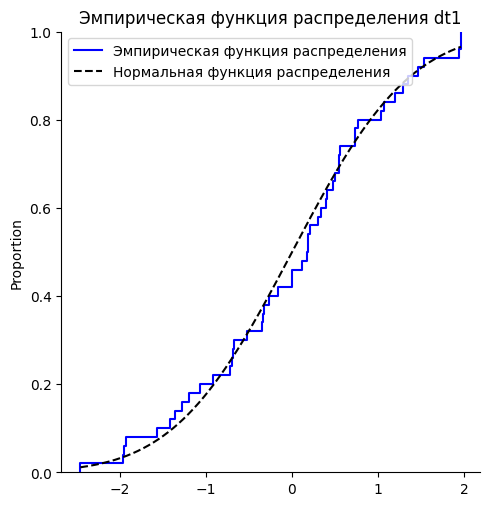

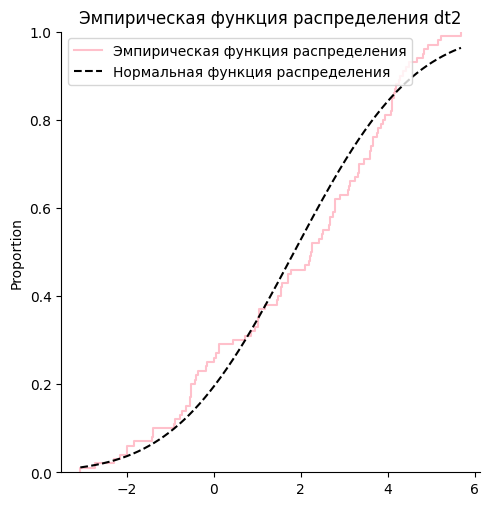

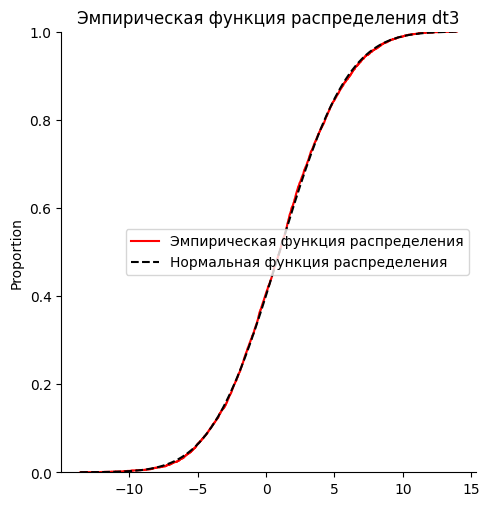

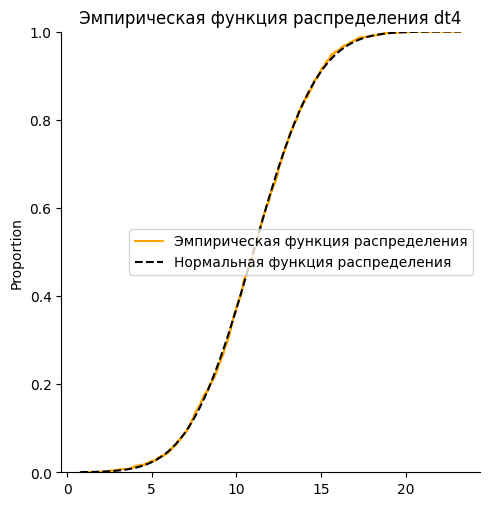

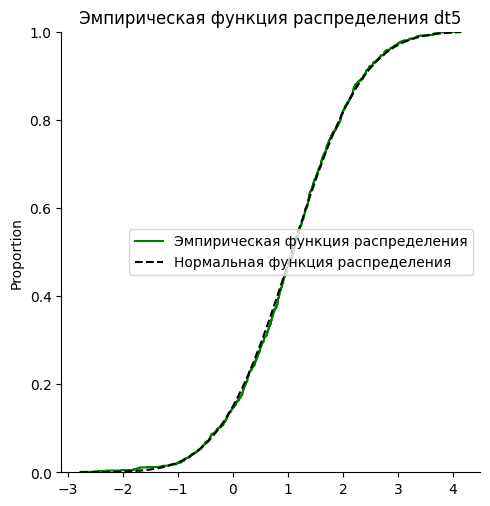

In [7]:
f(dt1, 'blue', 'dt1')
f(dt2, 'pink', 'dt2')
f(dt3, 'red', 'dt3')
f(dt4, 'orange', 'dt4')
f(dt5, 'green', 'dt5')

При нормальной выборке, но на малом количестве данных, ECDF показывает отклонение от CDF, чего нельзя сказать на выборках более большого размера.

**2) Анализ с помощью графиков квантилей.**

Сравниваем теоретические квантили нормального распределения и выборочные квантили данных. Если точки расположены вдоль линии, то распределение близко к нормальному. Также можно на собственных данных понять, имеют ли они тяжелые хвосты и выбросы или скошенность.

In [8]:
def qqgraph(data, data_name="", point_color="pink", line_color="black"):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    stats.probplot(data, dist="norm", plot=ax)
    ax.get_lines()[0].set_color(point_color)
    ax.get_lines()[1].set_color(line_color)
    ax.get_lines()[1].set_linewidth(2)
    plt.title(f"Q-Q график для нормальной выборки {data_name}")
    plt.xlabel("Теоретические квантили")
    plt.ylabel("Выборочные квантили")
    plt.show()

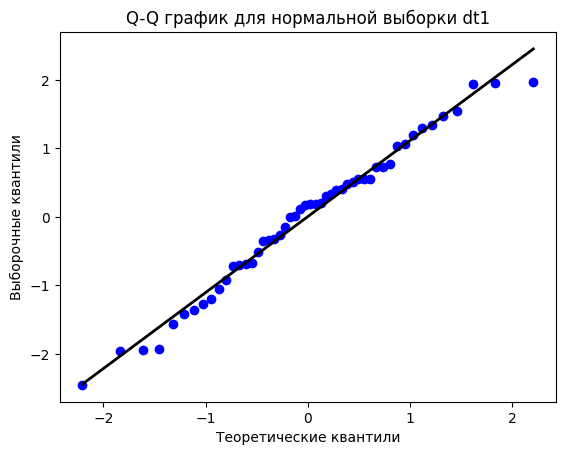

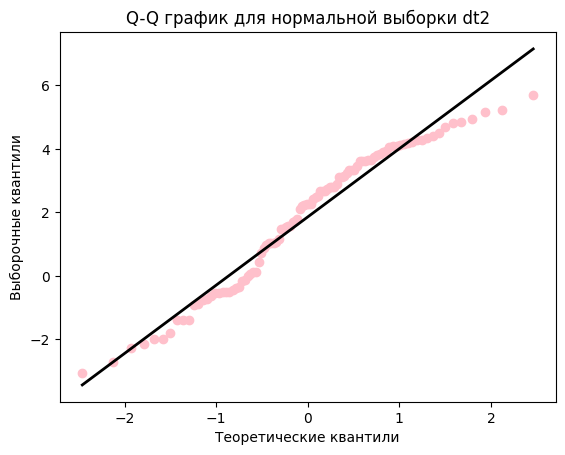

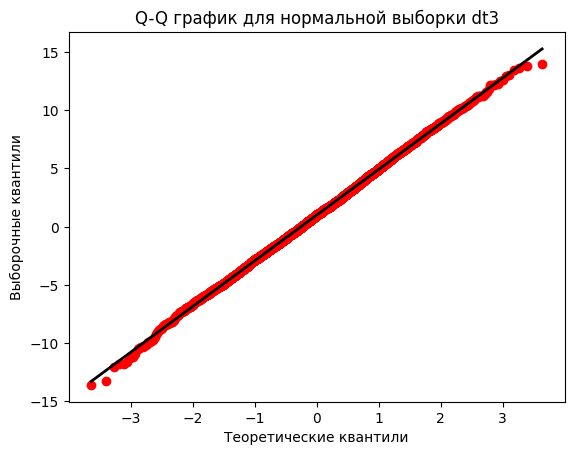

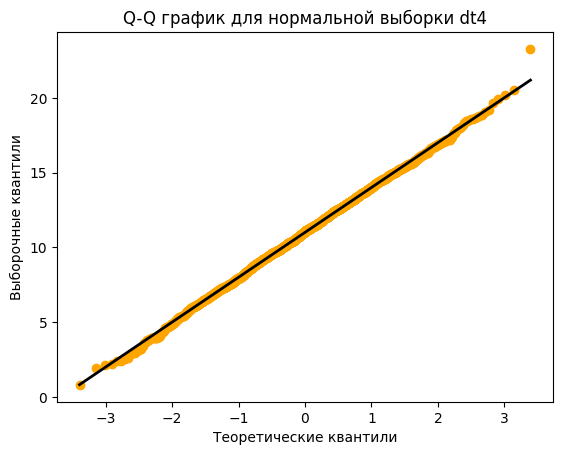

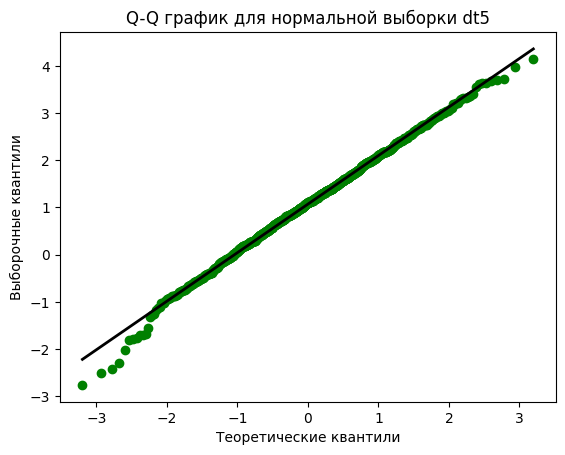

In [9]:
qqgraph(dt1, data_name="dt1", point_color='blue')
qqgraph(dt2, data_name="dt2", point_color='pink')
qqgraph(dt3, data_name="dt3", point_color='red')
qqgraph(dt4, data_name="dt4", point_color='orange')
qqgraph(dt5, data_name="dt5", point_color='green')

В целом, данные распределены действительно нормально, однако встечаются точки, отклоняющиеся от прямой (как, напрмиер, на последних четырех графиках).

**3) Анализ с помощью графиков метода огибающих.**

Метод огибающих поход на метод квантилей, только с добавлением доверительных границ (огибающих). На графиках Envelope на уровне 99%.
Если большинство точек сосредоточены внутри полосы, то рапсределение близко к нормальному.

In [10]:
def env(data, data_name="", color="pink", confidence=0.99):
    data_sorted = np.sort(data)
    n = len(data)
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    plt.scatter(osm, osr, color=color, edgecolor="black", label="Data")
    plt.plot(osm, slope * osm + intercept, color=color, lw=2, label="Q-Q Line")
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    se = (slope / np.sqrt(n)) * np.sqrt(1 + osm ** 2)
    upper_bound = slope * osm + intercept + z * se
    lower_bound = slope * osm + intercept - z * se
    plt.fill_between(osm, lower_bound, upper_bound, color=color, alpha=0.2, label=f"{int(confidence * 100)}% Envelope")
    plt.xlabel("Квантили нормального распределения")
    plt.ylabel("Наблюдаемые квантили")
    plt.title(f"Метод огибающих для нормальной выборки {data_name}")
    plt.legend(loc="best")
    plt.show()

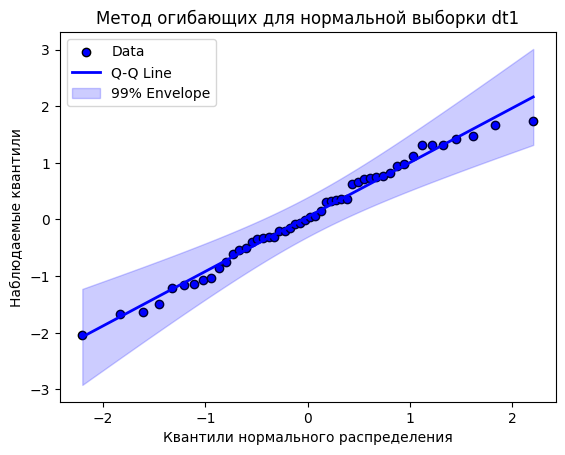

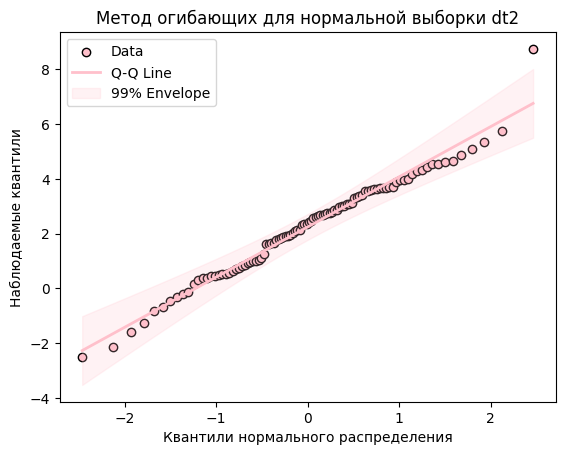

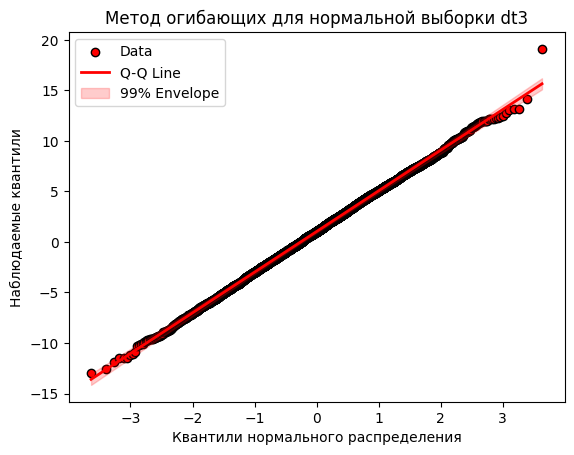

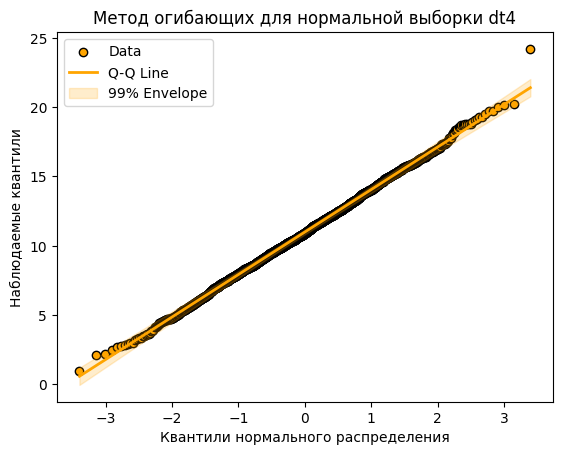

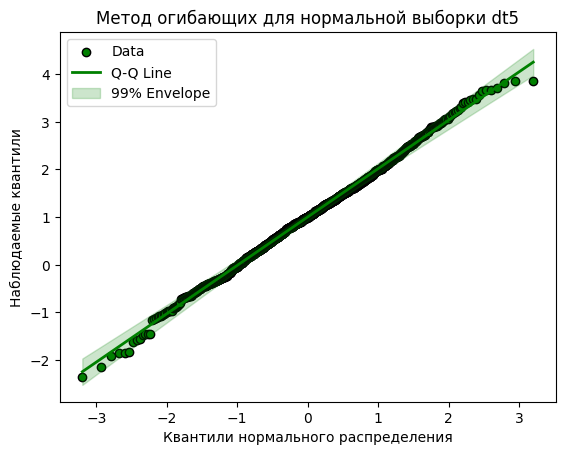

In [107]:
env(dt1, data_name="dt1", color="blue", confidence=0.99)
env(dt2, data_name="dt2", color="pink", confidence=0.99)
env(dt3, data_name="dt3", color="red", confidence=0.99)
env(dt4, data_name="dt4", color="orange", confidence=0.99)
env(dt5, data_name="dt5", color="green", confidence=0.99)

В данном случае, точки расположены внутри полосы, однако, опять же, есть по одной точке иногда, выходящей за границы.

**4) Гипотезы о нормальности.**

а) Критерий Колмогорова-Смирнова

In [11]:
from scipy.stats import kstest

print("dt1: ", kstest(dt1, 'norm', args=(0, 1)))
print("dt2: ", kstest(dt2, 'norm', args=(2, 2)))
print("dt3: ", kstest(dt3, 'norm', args=(1, 4)))
print("dt4: ", kstest(dt4, 'norm', args=(11, 3)))
print("dt5: ", kstest(dt5, 'norm', args=(1, 1)))

dt1:  KstestResult(statistic=np.float64(0.08876169907954512), pvalue=np.float64(0.7929922090340333), statistic_location=np.float64(0.1732224194569559), statistic_sign=np.int8(-1))
dt2:  KstestResult(statistic=np.float64(0.1156494963398092), pvalue=np.float64(0.1272754016481319), statistic_location=np.float64(0.125776225244997), statistic_sign=np.int8(1))
dt3:  KstestResult(statistic=np.float64(0.0153781440328139), pvalue=np.float64(0.18585260252034685), statistic_location=np.float64(2.3424861103964965), statistic_sign=np.int8(1))
dt4:  KstestResult(statistic=np.float64(0.011000523757445757), pvalue=np.float64(0.9666783757154153), statistic_location=np.float64(11.16175981046097), statistic_sign=np.int8(-1))
dt5:  KstestResult(statistic=np.float64(0.04430422694006225), pvalue=np.float64(0.0382741589022092), statistic_location=np.float64(0.8091057611148532), statistic_sign=np.int8(-1))


p-value > 0.05 верно для всех выборок, кроме dt2 (мало данных).

b) Критерий Шапиро-Уилка

In [12]:
from scipy.stats import shapiro

print("dt1: ", shapiro(dt1))
print("dt2: ", shapiro(dt2))
print("dt3: ", shapiro(dt3))
print("dt4: ", shapiro(dt4))
print("dt5: ", shapiro(dt5))

dt1:  ShapiroResult(statistic=np.float64(0.9798729296306992), pvalue=np.float64(0.5466166490304762))
dt2:  ShapiroResult(statistic=np.float64(0.9573136910241479), pvalue=np.float64(0.0025991796378961136))
dt3:  ShapiroResult(statistic=np.float64(0.9996003746755125), pvalue=np.float64(0.41733467163386007))
dt4:  ShapiroResult(statistic=np.float64(0.9993496397671384), pvalue=np.float64(0.7455289770771422))
dt5:  ShapiroResult(statistic=np.float64(0.997154364378237), pvalue=np.float64(0.07376370086086427))


p-value > 0.05 для всех выборок, поэтому все данные принадлежат нормальному распределению.

c) Критерий Андерсона-Дарлинга

In [13]:
from scipy.stats import anderson

print("dt1: ", anderson(dt1))
print("dt2: ", anderson(dt2))
print("dt3: ", anderson(dt3))
print("dt4: ", anderson(dt4))
print("dt5: ", anderson(dt5))

dt1:  AndersonResult(statistic=np.float64(0.2677865624445843), critical_values=array([0.538, 0.613, 0.736, 0.858, 1.021]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(0.004401976202988505), scale=np.float64(1.0898806905857765))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')
dt2:  AndersonResult(statistic=np.float64(1.4475274413643433), critical_values=array([0.555, 0.632, 0.759, 0.885, 1.053]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(1.8514529086538787), scale=np.float64(2.157009949866584))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')
dt3:  AndersonResult(statistic=np.float64(0.49136312100472423), critical_values=array([0.576, 0.655, 0.786, 0.917, 1.091]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(0.982941191356038), scale=n

d) Критерий Крамера фон Мизеса

In [14]:
from scipy.stats import cramervonmises

print("dt1: ", cramervonmises(dt1, 'norm', args=(0, 1)))
print("dt2: ", cramervonmises(dt2, 'norm', args=(2, 2)))
print("dt3: ", cramervonmises(dt3, 'norm', args=(1, 4)))
print("dt4: ", cramervonmises(dt4, 'norm', args=(11, 3)))
print("dt5: ", cramervonmises(dt5, 'norm', args=(1, 1)))

dt1:  CramerVonMisesResult(statistic=0.06358965722563542, pvalue=0.7936706681076375)
dt2:  CramerVonMisesResult(statistic=0.27619592439890545, pvalue=0.1579735650415507)
dt3:  CramerVonMisesResult(statistic=0.17873381758276055, pvalue=0.31276257516741435)
dt4:  CramerVonMisesResult(statistic=0.032267772124314135, pvalue=0.9681680924669287)
dt5:  CramerVonMisesResult(statistic=0.6458126924657954, pvalue=0.01724637960073261)


e) Критерий Колмогорова-Смирнова в модификации Лиллиефорса

In [15]:
from statsmodels.stats.diagnostic import lilliefors

print("dt1: ", lilliefors(dt1, 'norm'))
print("dt2: ", lilliefors(dt2, 'norm'))
print("dt3: ", lilliefors(dt3, 'norm'))
print("dt4: ", lilliefors(dt4, 'norm'))
print("dt5: ", lilliefors(dt5, 'norm'))

dt1:  (np.float64(0.08200304787376983), np.float64(0.5395764858464217))
dt2:  (np.float64(0.09660188133162306), np.float64(0.02322647744229622))
dt3:  (np.float64(0.011165121574361114), np.float64(0.1471708779482536))
dt4:  (np.float64(0.01187075589862352), np.float64(0.7247788648955199))
dt5:  (np.float64(0.01995205254533572), np.float64(0.5104381386357207))


f) Критерий Шапиро-Франсия

In [16]:
from sfrancia import shapiroFrancia

print("dt1: ", shapiroFrancia(dt1))
print("dt2: ", shapiroFrancia(dt2))
print("dt3: ", shapiroFrancia(dt3))
print("dt4: ", shapiroFrancia(dt4))
print("dt5: ", shapiroFrancia(dt5))

dt1:  {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9858569810012872), 'statistics z': np.float64(-0.5771498956179865), 'p-value': np.float64(0.71808089963686)}
dt2:  {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9624113221118099), 'statistics z': np.float64(2.4306838476514696), 'p-value': np.float64(0.0075351790912504555)}
dt3:  {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9996451883412902), 'statistics z': np.float64(0.09074739009647821), 'p-value': np.float64(0.46384665704862804)}
dt4:  {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9992602230645894), 'statistics z': np.float64(-0.17643658539704093), 'p-value': np.float64(0.5700245177573977)}
dt5:  {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.997108677948554), 'statistics z': np.float64(1.514870826909429), 'p-value': np.float64(0.0649025597806205)}


Все критерии показали, что данные распределены нормально.

# 7. Продемонстрировать пример анализа данных с помощью графиков квантилей, метода огибающих, а также стандартных процедур проверки гипотез о нормальности. Рассмотреть выборки малого и умеренного объемов.

В качестве малой выборки я возьму еще один датасет, содержащий информацию о фильмах.

In [17]:
films = pd.read_csv("movies.csv")

In [18]:
films.head()

,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
0,0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,1994-09-23,26.9579,8.712,28675
1,1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,26.5804,8.686,21701
2,2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,1974-12-20,15.6559,8.571,13099
3,3,424,Schindler's List,The true story of how businessman Oskar Schind...,1993-12-15,12.5642,8.565,16616
4,4,389,12 Angry Men,The defense and the prosecution have rested an...,1957-04-10,14.6028,8.549,9307


In [19]:
films.describe()

,Unnamed: 0,id,popularity,vote_average,vote_count
count,8560.000000,8.560000e+03,8560.000000,8560.000000,8560.000000
mean,4279.500000,2.163106e+05,4.370749,6.867912,2192.376869
std,2471.203485,2.879922e+05,21.398538,0.581178,3430.230375
min,0.000000,2.000000e+00,0.003400,5.900000,300.000000
25%,2139.750000,1.010800e+04,1.728925,6.400000,485.000000
50%,4279.500000,3.776850e+04,2.566650,6.812500,916.000000
75%,6419.250000,3.991332e+05,4.248675,7.298250,2237.000000
max,8559.000000,1.426776e+06,1274.226400,8.712000,37773.000000


Так как в моих данных нет переменных с нормальным распределением (и каждый критерий отверг гипотезу о нормальности), возьмем колонку, у которой распределение напоминает нормальное и стандатизируем его под параметры нормального распределения. Также были попытки изначально нормализовать данные, но они ни к чему не привели, ровно как и стандартизация, но я решила остановиться на втором варианте.
В качестве примеров я взяла колонку vote_average из датасета с фильмами и Annual_Income из датасета с кредитными характеристиками (обе колонки стандартизировала под нормальное распределение).

In [11]:
def normalize_column_inplace(df, column_name: str) -> None:
    df[column_name] = pd.to_numeric(df[column_name], errors="coerce")
    df[column_name] = (df[column_name] - df[column_name].min()) / (df[column_name].max() - df[column_name].min())

In [21]:
films_norm = films.copy()
col = "vote_average"

films_norm[col] = (films[col] - films[col].mean()) / films[col].std()
#films_norm[col] = (films_norm[col] - films_norm[col].min()) / (films_norm[col].max() - films_norm[col].min())

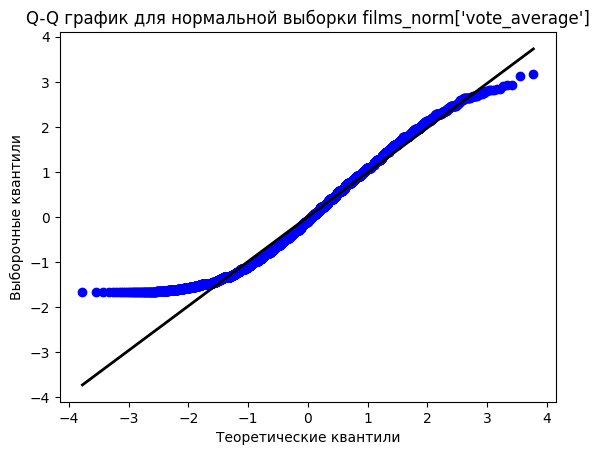

In [22]:
qqgraph(films_norm['vote_average'], data_name="films_norm['vote_average']", point_color="blue")

In [23]:
df = pd.read_csv('Credit_score_cleaned_data.csv')
df

,Customer_ID,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Last_Loan_9,Last_Loan_8,Last_Loan_7,Last_Loan_6,Last_Loan_5,Last_Loan_4,Last_Loan_3,Last_Loan_2,Last_Loan_1,Credit_Score
0,CUS_0x98ed,31,Journalist,22229.060,1672.421667,6,4,5.0,3,10,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Debt Consolidation Loan,Standard
1,CUS_0x36b4,43,Musician,17060.705,1685.725417,8,3,11.0,4,24,...,No Loan,No Loan,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Auto Loan,Auto Loan,Standard
2,CUS_0x105b,24,Accountant,34428.210,2575.017500,2,4,8.0,0,3,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Good
3,CUS_0x4c4a,21,Accountant,12613.920,1155.160000,4,6,13.0,3,14,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Personal Loan,Student Loan,Home Equity Loan,Standard
4,CUS_0x612f,31,Journalist,34775.160,3048.930000,7,9,25.0,5,20,...,No Loan,No Loan,No Loan,No Loan,Auto Loan,Mortgage Loan,Auto Loan,Payday Loan,Not Specified,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0xc52a,46,Writer,35032.660,2853.388333,10,6,33.0,7,48,...,No Loan,No Loan,Credit-Builder Loan,Student Loan,Personal Loan,Mortgage Loan,Payday Loan,Payday Loan,Student Loan,Poor
99996,CUS_0x83cc,34,Engineer,125047.240,10682.603333,2,5,9.0,0,11,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Standard
99997,CUS_0x6ae6,26,Lawyer,9045.485,644.664842,8,7,20.0,6,52,...,No Loan,No Loan,No Loan,Not Specified,Student Loan,Auto Loan,Not Specified,Student Loan,Auto Loan,Poor
99998,CUS_0x6f0c,20,Lawyer,53564.880,4207.740000,5,3,13.0,2,6,...,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Mortgage Loan,Personal Loan,Standard


In [24]:
df_norm = df.copy()
col = "Annual_Income"

df_norm[col] = (df[col] - df[col].mean()) / df[col].std()
#films_norm[col] = (films_norm[col] - films_norm[col].min()) / (films_norm[col].max() - films_norm[col].min())

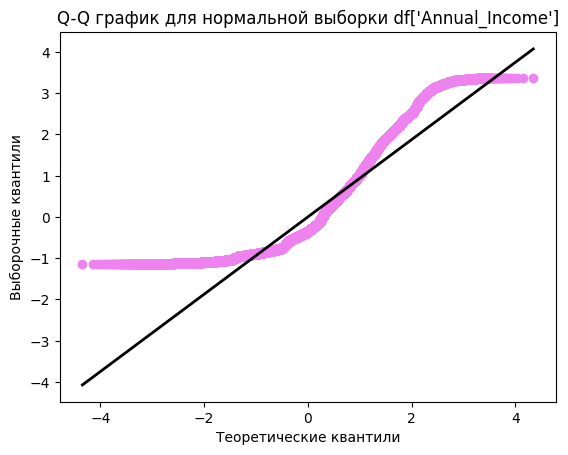

In [18]:
qqgraph(df_norm['Annual_Income'], data_name="df['Annual_Income']", point_color="violet")

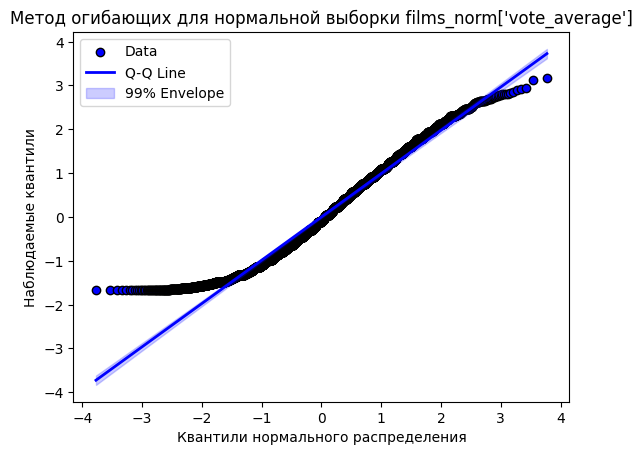

In [154]:
env(films_norm['vote_average'], data_name="films_norm['vote_average']", color="blue", confidence=0.99)

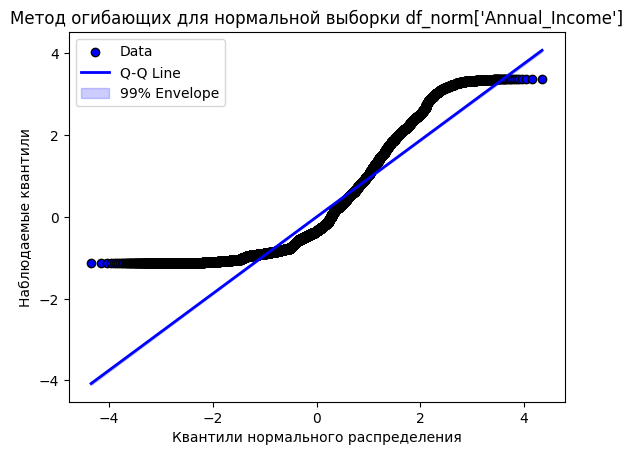

In [155]:
env(df_norm['Annual_Income'], data_name="df_norm['Annual_Income']", color="blue", confidence=0.99)

Стандартные процедуры проверки гипотез о нормальности

In [25]:
from scipy.stats import kstest

print("films_norm['vote_average'] ", kstest(films_norm['vote_average'], 'norm', args=(
    np.mean(films_norm['vote_average']),
    np.std(films_norm['vote_average'])
)))

films_norm['vote_average']  KstestResult(statistic=np.float64(0.05394974131947211), pvalue=np.float64(4.28019737748081e-22), statistic_location=np.float64(-0.6330452334451758), statistic_sign=np.int8(1))


In [26]:
print("df['Credit_History_Age']: ", kstest(df['Credit_History_Age'], 'norm', args=(np.mean(df['Credit_History_Age']), np.std(df['Credit_History_Age']))))

df['Credit_History_Age']:  KstestResult(statistic=np.float64(0.04699080035461023), pvalue=np.float64(2.4970101519169576e-192), statistic_location=np.int64(320), statistic_sign=np.int8(-1))


In [27]:
from scipy.stats import shapiro

print("films['vote_average']: ", shapiro(films['vote_average']))
print("df['Credit_Utilization_Ratio']: ", shapiro(df['Credit_Utilization_Ratio']))

films['vote_average']:  ShapiroResult(statistic=np.float64(0.9743755420250771), pvalue=np.float64(1.6197227671957507e-36))
df['Credit_Utilization_Ratio']:  ShapiroResult(statistic=np.float64(0.9785071914609981), pvalue=np.float64(3.741640918760014e-74))


C:\Users\catso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8560.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\catso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 100000.
  res = hypotest_fun_out(*samples, **kwds)


In [28]:
from scipy.stats import anderson

print("films['vote_average']: ", anderson(films['vote_average']))
print("df['Credit_Utilization_Ratio']: ", anderson(df['Credit_Utilization_Ratio']))

films['vote_average']:  AndersonResult(statistic=np.float64(47.76088683542184), critical_values=array([0.576, 0.656, 0.787, 0.918, 1.091]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(6.86791214953271), scale=np.float64(0.5811782951598085))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')
df['Credit_Utilization_Ratio']:  AndersonResult(statistic=np.float64(617.3592820444901), critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(32.2851725189436), scale=np.float64(5.116875070150907))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


In [29]:
from scipy.stats import cramervonmises

films1 = films['vote_average']
df1 = df['Credit_Utilization_Ratio']

mean_films = np.mean(films1)
std_films = np.std(films1)

mean_df = np.mean(df1)
std_df = np.std(df1)

print(cramervonmises(films1, 'norm', args=(mean_films, std_films)))
print(cramervonmises(df1, 'norm', args=(mean_df, std_df)))

CramerVonMisesResult(statistic=6.64028413041753, pvalue=6.791378570625284e-11)
CramerVonMisesResult(statistic=93.58851315214935, pvalue=3.1071775152824443e-08)


In [30]:
from statsmodels.stats.diagnostic import lilliefors

print("films['vote_average']: ", lilliefors(films['vote_average'], 'norm'))
print("df['Credit_Utilization_Ratio']: ", lilliefors(df['Credit_Utilization_Ratio'], 'norm'))

films['vote_average']:  (np.float64(0.05393766726662902), np.float64(0.0009999999999998899))
df['Credit_Utilization_Ratio']:  (np.float64(0.046650890457537286), np.float64(0.0009999999999998899))


In [31]:
from sfrancia import shapiroFrancia

print("films['vote_average']: ", shapiroFrancia(films['vote_average']))
print("df['Credit_Utilization_Ratio']: ", shapiroFrancia(df['Credit_Utilization_Ratio']))

films['vote_average']:  {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.9745428489484064), 'statistics z': np.float64(12.587738012695846), 'p-value': np.float64(1.2332007477585754e-36)}
df['Credit_Utilization_Ratio']:  {'method': 'Shapiro-Francia normality test', 'statistics W': np.float64(0.978522377045744), 'statistics z': np.float64(21.101004776643524), 'p-value': np.float64(3.893195469404012e-99)}


Не трудно заметить, что все критерии отвергли гипотезу о нормальности. Также можно по графикам оценить примерное рапсределение данных — они предположительно имеют хвосты, что является правдой.

# 4. Проверить, являются ли наблюдения выбросами с точки зрения формальных статистических критериев Граббса и Q-теста Диксона. Визуализировать результаты. 

**1. Критерий Граббса**

Критерий Граббса применим к выборкам с примерно нормальным распределением. Идея в том, чтобы найти значение среди данных, которое находится дальше всех от среднего, и посмотреть, насколько далеко оно находится по сравнению со стандартным отклонением. Для этого необходимо найти среднее и стандартное отклонение, значение, которое далье всего от среднего, и рассчитать статистику Граббса. Уровень значимости взят равным 0.05. Сравниваем статистику Граббса с критическим значением, после чего проводим сравнение, после которого решаем, удалять значение или нет.

In [22]:
def grubbs_test(series, alpha=0.05):
    x = series.dropna().astype(float).values
    outliers = []
    n = len(x)
    while True:
        mean_x = np.mean(x)
        std_x = np.std(x, ddof=1)
        deviations = np.abs(x - mean_x)
        max_dev_idx = np.argmax(deviations)
        G_calculated = deviations[max_dev_idx] / std_x
        t_crit = stats.t.ppf(1 - alpha / (2 * n), n - 2)
        G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))
        
        if G_calculated > G_crit:
            outlier_value = x[max_dev_idx]
            outliers.append(outlier_value)
            x = np.delete(x, max_dev_idx)
            n -= 1
        else:
            break
    return outliers

In [23]:
def grubbs_test_indices(series, alpha=0.05):
    x = series.dropna().astype(float).values
    indices = series.dropna().index.tolist()
    outlier_indices = []
    n = len(x)
    while n > 2:
        mean_x = np.mean(x)
        std_x = np.std(x, ddof=1)
        deviations = np.abs(x - mean_x)
        max_dev_idx = int(np.argmax(deviations))
        G_calculated = deviations[max_dev_idx] / std_x

        t_crit = stats.t.ppf(1 - alpha / (2 * n), n - 2)
        G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

        if G_calculated > G_crit:
            outlier_indices.append(indices[max_dev_idx])
            x = np.delete(x, max_dev_idx)
            indices.pop(max_dev_idx)
            n -= 1
        else:
            break
    return outlier_indices

Поиск и удаление выбросов будет происходить в сгенерированной выборке, так как при нормализации и стандартизации своих данных критерий выбросы не находил, хотя они есть.
Добавим вручную выбросы, чтобы убедиться, что критерий работает корректно.

In [24]:
#films_norm['vote_average'] = round(films_norm['vote_average'], 2)
#np.random.seed(42)
data = np.random.normal(loc=50, scale=5, size=10000)
#print(data)
data_with_outliers = np.append(data, [100, 120, 256, 201, 340])

In [25]:
df = pd.DataFrame({"value": data_with_outliers})
print(df.head())
outliers = grubbs_test(df["value"], alpha=0.05)
print("Найденные выбросы:", outliers)
#outliers = grubbs_test(films_norm['vote_average'], alpha=0.05)
#print(outliers)

       value
0  52.781331
1  56.636513
2  41.168231
3  50.820774
4  51.123086
Найденные выбросы: [np.float64(340.0), np.float64(256.0), np.float64(201.0), np.float64(120.0), np.float64(100.0)]


Проверим выбросы с помощью boxplot.

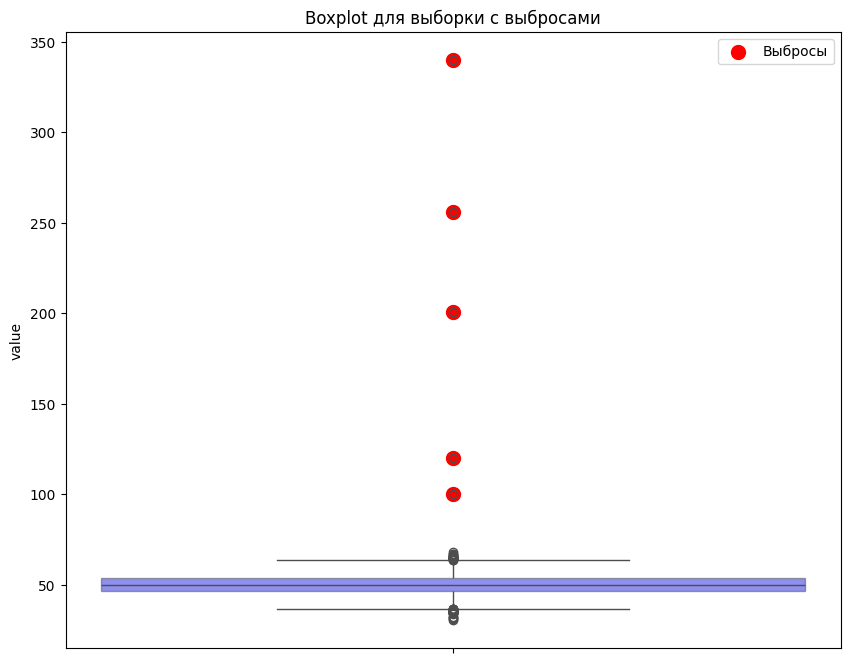

In [31]:
plt.figure(figsize=(10, 8))
sns.boxplot(
    y="value",
    data=df,
    color="blue",
    boxprops=dict(alpha=0.5)
)
plt.scatter(
    x=[0]*len(outliers), 
    y=outliers,
    color="red", 
    s=100, 
    label="Выбросы"
)
plt.title("Boxplot для выборки с выбросами")
plt.legend()
plt.show()

**2. Q-тест Диксона.**

В первую очередь, Q-тест Диксона применим к выборкам от 3 до 30 наблюдений. Он проверяет одно значение, которое находится слишком далеко от отальных наблюдений относительно обего разброса данных. Суть следующая: сортируем выборку по возрастанию, находим диапозон, как разность между x(1) и x(n), и рассчитываем коэффициенты для минимального и максимального значений. Каждое это значение будет показывать, насколько далеко крайнее наблюдение от ближайшего наблюдения относительно диапозона. Критическое значение уже известно и сразу добавлено в код для уровня значимости 0.05.

In [32]:
Q_CRIT_005 = {
    3: 0.941, 4: 0.765, 5: 0.642, 6: 0.560, 7: 0.507, 8: 0.468, 9: 0.437, 10: 0.412,
    11: 0.392, 12: 0.376, 13: 0.361, 14: 0.349, 15: 0.338, 16: 0.329, 17: 0.320,
    18: 0.313, 19: 0.306, 20: 0.300, 21: 0.295, 22: 0.290, 23: 0.285, 24: 0.281,
    25: 0.277, 26: 0.273, 27: 0.270, 28: 0.267, 29: 0.263, 30: 0.260
}
def dixon_qtest(data, alpha=0.05):
    x = np.sort(np.asarray(data, dtype=float))
    n = len(x)
    Qcrit = Q_CRIT_005[n]
    R = x[-1] - x[0]

    Q_min = (x[1] - x[0]) / R
    min_outlier = Q_min > Qcrit

    Q_max = (x[-1] - x[-2]) / R
    max_outlier = Q_max > Qcrit

    return {
        "min_outlier": min_outlier,
        "max_outlier": max_outlier,
        "Q_min": Q_min,
        "Q_max": Q_max,
        "Qcrit": Qcrit
    }

В качестве выборки снова возьмем сгенерированную выборку из нормального распределения, размером 25 наблюдений и добавим один выброс — значение 360.

In [35]:
data1 = np.random.normal(loc=50, scale=5, size=25)
data_with_outliers1 = np.append(data1, [360])

outliers1 = dixon_qtest(data_with_outliers1, alpha=0.05)
print(outliers1)

{'min_outlier': np.False_, 'max_outlier': np.True_, 'Q_min': np.float64(0.020443770821116432), 'Q_max': np.float64(0.9320250132503334), 'Qcrit': 0.273}


 Максимальное значение в выборке действительно является выбросом, в то время как минимальное — нет. Это видно в выводе: min_outlier: False, max_outlier: True.

# 8. Продемонстрировать применение для проверки различных гипотез и различных доверительных уровней (0.9, 0.95, 0.99) следующих критериев.

## a. Стьюдента, включая односторонние варианты, когда проверяемая нулевая гипотеза заключается в том, что одно из сравниваемых средних значений больше (или меньше) другого. Реализовать оценку мощности критериев при заданном объеме выборки или определения объема выборки для достижения заданной мощности.

Снова будем работать с датасетом, включающим в себя показатели шахматных партий.

In [32]:
chess = pd.read_csv("games.csv")
chess.head(5)

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [137]:
print(chess["white_rating"].mean())

1596.6318675840064


1. Двусторонний критерий Стьюдента

In [138]:
from pingouin import ttest
mu = 1596.9

In [139]:
ttest(chess['white_rating'], mu, alternative = 'two-sided', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,-0.130383,20057,two-sided,0.896264,"[1593.249082004866, 1600.0146531631467]",0.000921,0.008,0.051949


p_value = 0.896264 > 0.05. Нет оснований отвергать Н1 гипотезу.

In [140]:
ttest(chess['white_rating'], mu, alternative = 'two-sided', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.130383,20057,two-sided,0.896264,"[1592.6, 1600.66]",0.000921,0.008,0.051949


In [141]:
ttest(chess['white_rating'], mu, alternative = 'two-sided', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-0.130383,20057,two-sided,0.896264,"[1591.3341894937732, 1601.9295456742395]",0.000921,0.008,0.051949


2.1 Односторонние критерии Стьюдента. Greater.

In [142]:
ttest(chess['white_rating'], mu, alternative = 'greater', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,-0.130383,20057,greater,0.551868,"[1593.9962794487594, inf]",0.000921,0.016,0.03793


In [143]:
ttest(chess['white_rating'], mu, alternative = 'greater', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.130383,20057,greater,0.551868,"[1593.25, inf]",0.000921,0.016,0.03793


In [144]:
ttest(chess['white_rating'], mu, alternative = 'greater', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-0.130383,20057,greater,0.551868,"[1591.8473679815054, inf]",0.000921,0.016,0.03793


2.2 Односторонние критерии Стьюдента. Less.

In [145]:
ttest(chess['white_rating'], mu, alternative = 'less', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,-0.130383,20057,less,0.448132,"[-inf, 1599.2674557192533]",0.000921,0.016,0.064953


In [146]:
ttest(chess['white_rating'], mu, alternative = 'less', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.130383,20057,less,0.448132,"[-inf, 1600.01]",0.000921,0.016,0.064953


In [147]:
ttest(chess['white_rating'], mu, alternative = 'less', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-0.130383,20057,less,0.448132,"[-inf, 1601.4163671865074]",0.000921,0.016,0.064953


3. Определение объема выборки для достижения заданной мощности


effect_size_rating = 10 — в шахматах разница в 10 пунктов рейтинга считается значимой.

In [196]:
from statsmodels.stats.power import TTestPower, TTestIndPower, FTestAnovaPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

print("ОЦЕНКА МОЩНОСТИ Т-ТЕСТА ДЛЯ РЕЙТИНГОВ БЕЛЫХ")
print("=" * 50)

white_rating_mean = chess['white_rating'].mean()
white_rating_std = chess['white_rating'].std()
effect_size_rating = 10
alpha = 0.05
n = len(chess)

cohen_d = effect_size_rating / white_rating_std

power_analysis = TTestPower()
current_power = power_analysis.power(effect_size=cohen_d, nobs=n, alpha=alpha, alternative='two-sided')

print(f"Текущий объем выборки: {n}")
print(f"Среднее: {white_rating_mean:.2f}, STD: {white_rating_std:.2f}")
print(f"Размер эффекта (Коэн d): {cohen_d:.4f}")
print(f"Текущая мощность теста: {current_power:.4f}")

print("\nОПРЕДЕЛЕНИЕ НЕОБХОДИМОГО ОБЪЕМА ВЫБОРКИ")
print("=" * 50)

desired_power = 0.8
required_n = power_analysis.solve_power(effect_size=cohen_d, power=desired_power, alpha=alpha, alternative='two-sided')

print(f"Желаемая мощность: {desired_power}")
print(f"Необходимый объем выборки: {required_n:.0f}")
print(f"Текущая выборка достаточна: {'ДА' if n >= required_n else 'НЕТ'}")

ОЦЕНКА МОЩНОСТИ Т-ТЕСТА ДЛЯ РЕЙТИНГОВ БЕЛЫХ
Текущий объем выборки: 20058
Среднее: 1596.63, STD: 291.25
Размер эффекта (Коэн d): 0.0343
Текущая мощность теста: 0.9981

ОПРЕДЕЛЕНИЕ НЕОБХОДИМОГО ОБЪЕМА ВЫБОРКИ
Желаемая мощность: 0.8
Необходимый объем выборки: 6660
Текущая выборка достаточна: ДА


Видно, что есть высокий шанс обнаружить разницу в 10 баллов рейтинга.

2. Двухвыборочный критерий Стьюдента


Будем рассматривать рейтинг белых и черных.

In [150]:
print(chess['white_rating'].mean(), chess['black_rating'].mean())

1596.6318675840064 1588.8319872370128


1. Двухсторонний критерий Стьюдента


In [151]:
ttest(chess['white_rating'], chess['black_rating'], alternative = 'two-sided', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,2.68292,40114,two-sided,0.007301,"[3.0177934290784987, 12.581967264908766]",0.02679,0.411,0.765129


In [152]:
ttest(chess['white_rating'], chess['black_rating'], alternative = 'two-sided', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.68292,40114,two-sided,0.007301,"[2.1, 13.5]",0.02679,0.411,0.765129


In [153]:
ttest(chess['white_rating'], chess['black_rating'], alternative = 'two-sided', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,2.68292,40114,two-sided,0.007301,"[0.31098220215667494, 15.288778491830591]",0.02679,0.411,0.765129


2.1 Односторонние критерии Стьюдента. Greater.


In [154]:
ttest(chess['white_rating'], chess['black_rating'], alternative = 'greater', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,2.68292,40114,greater,0.003651,"[4.0740470763324526, inf]",0.02679,0.823,0.85037


In [155]:
ttest(chess['white_rating'], chess['black_rating'], alternative = 'greater', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.68292,40114,greater,0.003651,"[3.02, inf]",0.02679,0.823,0.85037


In [156]:
ttest(chess['white_rating'], chess['black_rating'], alternative = 'greater', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,2.68292,40114,greater,0.003651,"[1.0363694806423653, inf]",0.02679,0.823,0.85037


2.2 Односторонние критерии Стьюдента. Less.


In [157]:
ttest(chess['white_rating'], chess['black_rating'], alternative = 'less', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,2.68292,40114,less,0.996349,"[-inf, 11.525713617654812]",0.02679,0.823,0.000008


In [158]:
ttest(chess['white_rating'], chess['black_rating'], alternative = 'less', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.68292,40114,less,0.996349,"[-inf, 12.58]",0.02679,0.823,0.000008


In [159]:
ttest(chess['white_rating'], chess['black_rating'], alternative = 'less', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,2.68292,40114,less,0.996349,"[-inf, 14.563391213344898]",0.02679,0.823,0.000008


# b. Ранговый критерий Уилкоксона-Манна-Уитни

In [160]:
print(chess['white_rating'].mean(), chess['black_rating'].mean())

1596.6318675840064 1588.8319872370128


In [161]:
print('(two-sided):\t', stats.mannwhitneyu(chess['white_rating'], chess['black_rating'], alternative='two-sided'))
print('(greater):\t', stats.mannwhitneyu(chess['white_rating'], chess['black_rating'], alternative='greater'))
print('(less):\t\t', stats.mannwhitneyu(chess['white_rating'], chess['black_rating'], alternative='less'))

(two-sided):	 MannwhitneyuResult(statistic=np.float64(204001653.5), pvalue=np.float64(0.014330248178688576))
(greater):	 MannwhitneyuResult(statistic=np.float64(204001653.5), pvalue=np.float64(0.007165124089344288))
(less):		 MannwhitneyuResult(statistic=np.float64(204001653.5), pvalue=np.float64(0.9928348930633055))


c. Проверка гипотез об однородности дисперсий


In [162]:
def fisher_test(x, y, alternative='two_sided'):
    df1 = len(x) - 1
    df2 = len(y) - 1
    f = x.var(ddof=1) / y.var(ddof=1)
    if alternative == 'greater':
        pvalue = 1 - stats.f.cdf(f, df1, df2)
    elif alternative == 'less':
        pvalue = stats.f.cdf(f, df1, df2)
    elif alternative == 'two_sided':
        pvalue =  min(2 * min(stats.f.cdf(f, df1, df2), 1 - stats.f.cdf(f, df1, df2)), 1)
    else:
        return ValueError("Альтернатива должна быть 'greater', 'less' или 'two-sided'")
    return pvalue

In [163]:
print(chess['white_rating'].var(), chess['black_rating'].var())

84828.52887820912 84702.02661399954


In [164]:
print('two-sided (DX != DY): ', fisher_test(chess['white_rating'], chess['black_rating'], alternative='two_sided'))
print('greater (DX > DY): ', fisher_test(chess['white_rating'], chess['black_rating'], alternative='greater'))
print('less (DX < DY): ', fisher_test(chess['white_rating'], chess['black_rating'], alternative='less'))

two-sided (DX != DY):  0.9158391175194258
greater (DX > DY):  0.4579195587597129
less (DX < DY):  0.5420804412402871


2. Критерий Левене


In [165]:
print(chess['white_rating'].std(), chess['black_rating'].std())

291.2533757370189 291.03612596033423


In [166]:
stats.levene(chess['white_rating'], chess['black_rating'], center='median')

LeveneResult(statistic=np.float64(6.840727080423392e-05), pvalue=np.float64(0.993400917724542))

Дисперсии равны.

3. Критерий Бартлетта


In [167]:
print(chess['white_rating'].var(), chess['black_rating'].var())

84828.52887820912 84702.02661399954


In [168]:
stats.bartlett(chess['white_rating'], chess['black_rating'])

BartlettResult(statistic=np.float64(1.282151354777368), pvalue=np.float64(0.2574994101984145))

Дисперсии равны.

4. Критерий Флигнера-Килина


In [169]:
stats.fligner(chess['white_rating'], chess['black_rating'], center='median')

FlignerResult(statistic=np.float64(0.003039910165196831), pvalue=np.float64(0.9560306095669405))

Дисперсии равны.

## 9. Исследовать корреляционные взаимосвязи в данных с помощью коэффициентов корреляции Пирсона, Спирмена и Кендалла.

In [170]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau

1. Пирсон

для пирсона необходимы норм распрееления

In [171]:
pearsonr(chess['white_rating'], chess['black_rating'])

PearsonRResult(statistic=np.float64(0.6341707768853486), pvalue=np.float64(0.0))

2. Спирмен

In [172]:
print(spearmanr(df['Annual_Income'], df['Monthly_Inhand_Salary']))

SignificanceResult(statistic=np.float64(0.9944637076578631), pvalue=np.float64(0.0))


In [173]:
print(spearmanr(chess['white_rating'], chess['turns']))

SignificanceResult(statistic=np.float64(0.1396652193605909), pvalue=np.float64(6.49899218472132e-88))


3. Корреляция Кендалла


In [174]:
print(kendalltau(chess['black_rating'], chess['opening_ply']))

SignificanceResult(statistic=np.float64(0.15777540134189985), pvalue=np.float64(4.143303399963568e-220))


In [175]:
print(kendalltau(df['Monthly_Inhand_Salary'], df['Monthly_Balance']))

SignificanceResult(statistic=np.float64(0.4517672174096344), pvalue=np.float64(0.0))


## 10. Продемонстрировать использование методов хи-квадрат, точного теста Фишера, теста МакНемара, Кохрана-Мантеля-Хензеля.

In [176]:
from scipy.stats import chi2_contingency

cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
results = []

for col in cat_cols:
    ct = pd.crosstab(df[col], df['Credit_Score'])
    chi2, p_value, dof, expected = chi2_contingency(ct)
    
    if p_value < 0.001:
        strength = 'очень сильное'
    elif p_value < 0.01:
        strength = 'сильное'
    elif p_value < 0.05:
        strength = 'умеренное'
    else:
        strength = 'слабое/отсутствует'
    
    results.append({
        'Переменная': col,
        'Chi2': round(chi2, 1),
        'P-value': round(p_value, 4),
        'Степени свободы': dof,
        'Влияние': strength
    })

res_df = pd.DataFrame(results).set_index('Переменная')
print(res_df.to_string())

                          Chi2  P-value  Степени свободы        Влияние
Переменная                                                             
Occupation               180.7      0.0               28  очень сильное
Credit_Mix             40489.4      0.0                4  очень сильное
Payment_of_Min_Amount  22420.4      0.0                2  очень сильное
Payment_Behaviour       1645.9      0.0               10  очень сильное


In [181]:
from scipy.stats import fisher_exact

cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
results = []

for col in cat_cols:
    ct = pd.crosstab(df[col], df['Credit_Score'])
    
    if ct.shape != (2, 2):
        top_categories = df[col].value_counts().head(2).index
        top_target = df['Credit_Score'].value_counts().head(2).index
        
        filtered_df = df[df[col].isin(top_categories) & df['Credit_Score'].isin(top_target)]
        ct = pd.crosstab(filtered_df[col], filtered_df['Credit_Score'])
    
    odds_ratio, p_value = fisher_exact(ct)
    
    if p_value < 0.001:
        strength = 'очень сильное'
    elif p_value < 0.01:
        strength = 'сильное'
    elif p_value < 0.05:
        strength = 'умеренное'
    else:
        strength = 'слабое/отсутствует'
    
    if odds_ratio > 1:
        direction = 'положительная'
    elif odds_ratio < 1:
        direction = 'отрицательная'
    else:
        direction = 'нейтральная'
    
    results.append({
        'Переменная': col,
        'Odds Ratio': round(odds_ratio, 3),
        'P-value': round(p_value, 4),
        'Влияние': strength,
        'Направление': direction
    })

res_df = pd.DataFrame(results).set_index('Переменная')
print(res_df.to_string())

                       Odds Ratio  P-value        Влияние    Направление
Переменная                                                              
Occupation                  1.177      0.0  очень сильное  положительная
Credit_Mix                  1.536      0.0  очень сильное  положительная
Payment_of_Min_Amount       0.398      0.0  очень сильное  отрицательная
Payment_Behaviour           0.775      0.0  очень сильное  отрицательная


In [197]:
print(df['Occupation'].unique().tolist())
print(df['Credit_Score'].unique().tolist())

['Journalist', 'Musician', 'Accountant', 'Entrepreneur', 'Developer', 'Engineer', 'Media_Manager', 'Manager', 'Mechanic', 'Architect', 'Doctor', 'Lawyer', 'Scientist', 'Teacher', 'Writer']
['Standard', 'Good', 'Poor']


In [179]:
from scipy.stats import fisher_exact
print("Доступные профессии:")
print(df['Occupation'].unique())
print("\nДоступные кредитные рейтинги:")
print(df['Credit_Score'].unique())

occupation1 = 'Scientist'
occupation2 = 'Teacher'
target1 = 'Good'
target2 = 'Poor'

mask = (df['Occupation'].isin([occupation1, occupation2])) & (df['Credit_Score'].isin([target1, target2]))
temp_df = df[mask]

print(f"\nАнализ: {occupation1} vs {occupation2} по кредитным рейтингам {target1} vs {target2}")
print(f"Количество записей для анализа: {len(temp_df)}")

ct = pd.crosstab(temp_df['Occupation'], temp_df['Credit_Score'])
print("\nТаблица сопряженности:")
print(ct)

if ct.shape == (2, 2):
    odds_ratio, p_value = fisher_exact(ct)
    
    print(f"\nРезультаты точного теста Фишера:")
    print(f"Odds Ratio: {odds_ratio:.3f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("Статистически значимая связь обнаружена!")
        if odds_ratio > 1:
            print(f"{occupation1} имеет в {odds_ratio:.1f} раз БОЛЬШИЕ шансы иметь рейтинг '{target1}' по сравнению с {occupation2}")
        else:
            print(f"{occupation1} имеет в {1/odds_ratio:.1f} раз МЕНЬШИЕ шансы иметь рейтинг '{target1}' по сравнению с {occupation2}")
    else:
        print("Статистически значимой связи не обнаружено")
else:
    print(f"\nОшибка: таблица имеет размер {ct.shape} вместо 2x2")
    print("Возможно, для некоторых комбинаций нет данных")

Доступные профессии:
['Journalist' 'Musician' 'Accountant' 'Entrepreneur' 'Developer'
 'Engineer' 'Media_Manager' 'Manager' 'Mechanic' 'Architect' 'Doctor'
 'Lawyer' 'Scientist' 'Teacher' 'Writer']

Доступные кредитные рейтинги:
['Standard' 'Good' 'Poor']

Анализ: Scientist vs Teacher по кредитным рейтингам Good vs Poor
Количество записей для анализа: 6514

Таблица сопряженности:
Credit_Score  Good  Poor
Occupation              
Scientist     1201  2062
Teacher       1224  2027

Результаты точного теста Фишера:
Odds Ratio: 0.965
P-value: 0.4890
Статистически значимой связи не обнаружено


Видно, что профессия не является значимым фактором для кредитного рейтинга.

3. Тест МакНемара


In [180]:
from statsmodels.stats.contingency_tables import mcnemar

chess['white_rating_change'] = chess['white_rating'].diff() > 0
chess['black_rating_change'] = chess['black_rating'].diff() > 0

table = pd.crosstab(chess['white_rating_change'], chess['black_rating_change'])
print("Таблица изменений рейтингов:")
print(table)

result = mcnemar(table, exact=False)
print(f"Статистика МакНемара: {result.statistic:.3f}")
print(f"P-value: {result.pvalue:.4f}")

Таблица изменений рейтингов:
black_rating_change  False  True 
white_rating_change              
False                 4728   5860
True                  5690   3780
Статистика МакНемара: 2.473
P-value: 0.1158


Изменения рейтингов белых и черных не зависят друг от друга.

In [119]:
from statsmodels.stats.contingency_tables import StratifiedTable

df['Default'] = df['Credit_Score'].isin(['Bad', 'Poor']).astype(int)
df['Pays_Minimum'] = (df['Payment_of_Min_Amount'] == 'Yes').astype(int)

df['Income_Group'] = pd.qcut(df['Annual_Income'], q=3, labels=['Low', 'Medium', 'High'])

stratified_data = []
for income_group in ['Low', 'Medium', 'High']:
    subset = df[df['Income_Group'] == income_group]
    table = pd.crosstab(subset['Pays_Minimum'], subset['Default'])
    if table.shape == (2, 2):
        stratified_data.append(table.values)

if len(stratified_data) >= 2:
    cmh_test = StratifiedTable(stratified_data)
    result = cmh_test.test_null_odds()
    
    print("Результаты теста Кохрана-Мантеля-Хензеля:")
    print(f"Статистика: {result.statistic:.4f}")
    print(f"p-значение: {result.pvalue:.4f}")
    print(f"Объединенный OR: {cmh_test.oddsratio_pooled:.3f}")
    print(f"95% ДИ: {cmh_test.oddsratio_pooled_confint()}")

Результаты теста Кохрана-Мантеля-Хензеля:
Статистика: 6518.4634
p-значение: 0.0000
Объединенный OR: 3.845
95% ДИ: (np.float64(3.716626060825971), np.float64(3.977231938945471))


Любой клиент, который платит только минимальный платеж, будет иметь низкий кредитный рейтинг.

## 11. Проверить наличие мультиколлинеарности в данных с помощью корреляционной матрицы и фактора инфляции дисперсии.

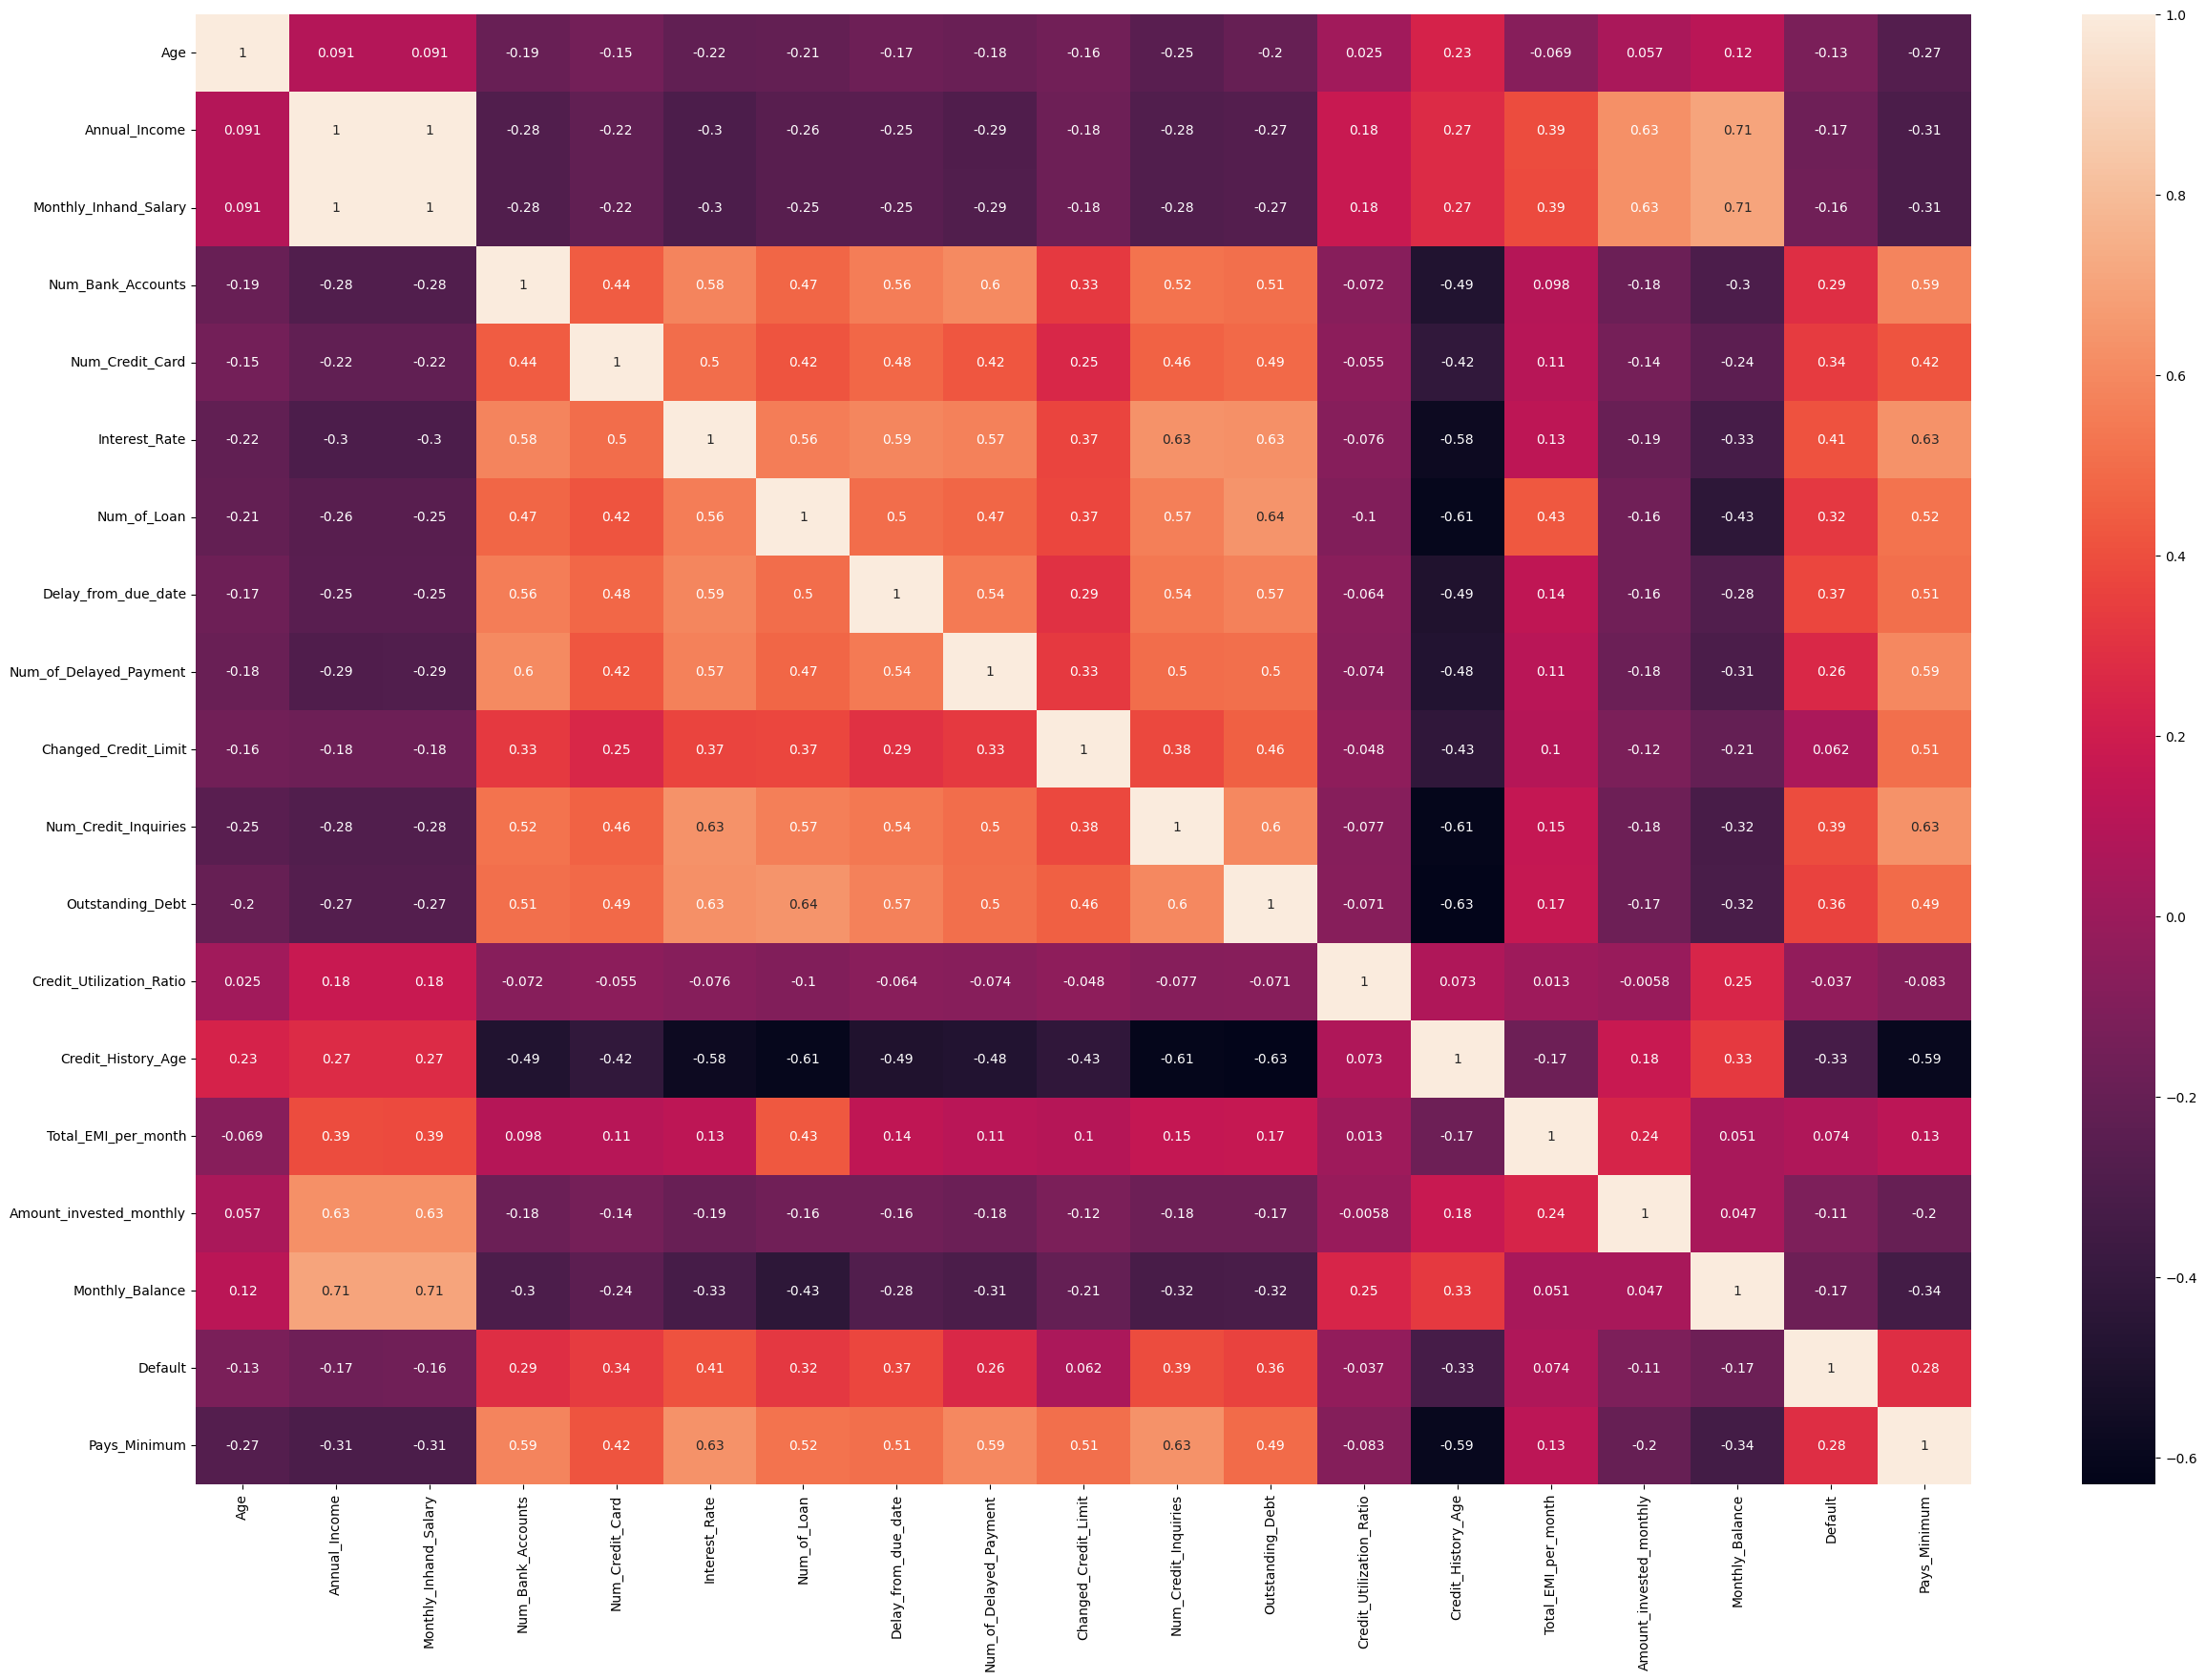

In [120]:
num_df = df.select_dtypes(include='number')
plt.figure(figsize=(30,20))
sns.heatmap(num_df.corr(), annot=True);

Топ корреляции:

1. Annual_Income – Monthly_Inhand_Salary ρ = +0.998
2. Monthly_Inhand_Salary – Monthly_Balance ρ = +0.707
3. Annual_Income – Monthly_Balance ρ = +0.706

In [182]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

numeric_cols = df.select_dtypes(include=[np.number]).columns

if 'Default' in numeric_cols:
    numeric_cols = numeric_cols.drop('Default')
if 'Credit_Score' in df.columns:
    numeric_cols = numeric_cols.drop('Credit_Score') if 'Credit_Score' in numeric_cols else numeric_cols

X = df[numeric_cols].copy()
X_clean = X.dropna()
X_with_const = add_constant(X_clean)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                   for i in range(X_with_const.shape[1])]

vif_data = vif_data.sort_values("VIF", ascending=False)

print("ФАКТОР ИНФЛЯЦИИ ДИСПЕРСИИ (VIF):")
print(vif_data.to_string(index=False))

ФАКТОР ИНФЛЯЦИИ ДИСПЕРСИИ (VIF):
                Variable        VIF
   Monthly_Inhand_Salary 285.878786
           Annual_Income 280.159761
                   const 108.793316
         Monthly_Balance   6.382868
 Amount_invested_monthly   4.410602
             Num_of_Loan   3.071730
            Pays_Minimum   2.682115
        Outstanding_Debt   2.636187
           Interest_Rate   2.535276
    Num_Credit_Inquiries   2.328159
      Credit_History_Age   2.234103
       Num_Bank_Accounts   2.040559
  Num_of_Delayed_Payment   2.006913
     Delay_from_due_date   1.988418
     Total_EMI_per_month   1.979965
         Num_Credit_Card   1.530550
    Changed_Credit_Limit   1.484930
                     Age   1.097094
Credit_Utilization_Ratio   1.066139


## 12. Исследовать зависимости в данных с помощью дисперсионного анализа


In [198]:
print("ОДНОФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ")
groups_occupation = [group['Annual_Income'].values for name, group in df.groupby('Occupation') if len(group) > 5]
if len(groups_occupation) >= 2:
    f_stat, p_value = stats.f_oneway(*groups_occupation)
    print(f"Occupation и Annual_Income: F = {f_stat:.3f}, p = {p_value:.4f}")

groups_credit_mix = [group['Annual_Income'].values for name, group in df.groupby('Credit_Mix') if len(group) > 5]
if len(groups_credit_mix) >= 2:
    f_stat, p_value = stats.f_oneway(*groups_credit_mix)
    print(f"Credit_Mix и Annual_Income: F = {f_stat:.3f}, p = {p_value:.4f}")

groups_payment = [group['Monthly_Inhand_Salary'].values for name, group in df.groupby('Payment_of_Min_Amount') if len(group) > 5]
if len(groups_payment) >= 2:
    f_stat, p_value = stats.f_oneway(*groups_payment)
    print(f"Payment_of_Min_Amount и Monthly_Inhand_Salary: F = {f_stat:.3f}, p = {p_value:.4f}")

groups_loan = [group['Num_of_Loan'].values for name, group in df.groupby('Occupation') if len(group) > 5]
if len(groups_loan) >= 2:
    f_stat, p_value = stats.f_oneway(*groups_loan)
    print(f"Occupation и Num_of_Loan: F = {f_stat:.3f}, p = {p_value:.4f}")

groups_debt = [group['Outstanding_Debt'].values for name, group in df.groupby('Credit_Mix') if len(group) > 5]
if len(groups_debt) >= 2:
    f_stat, p_value = stats.f_oneway(*groups_debt)
    print(f"Credit_Mix и Outstanding_Debt: F = {f_stat:.3f}, p = {p_value:.4f}")

ОДНОФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ
Occupation и Annual_Income: F = 3.708, p = 0.0000
Credit_Mix и Annual_Income: F = 6727.469, p = 0.0000
Payment_of_Min_Amount и Monthly_Inhand_Salary: F = 10542.863, p = 0.0000
Occupation и Num_of_Loan: F = 7.981, p = 0.0000
Credit_Mix и Outstanding_Debt: F = 72930.577, p = 0.0000


In [199]:
print("ОДНОФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ - ШАХМАТЫ")

groups_victory = [group['turns'].values for name, group in chess.groupby('victory_status') if len(group) > 5]
if len(groups_victory) >= 2:
    f_stat, p_value = stats.f_oneway(*groups_victory)
    print(f"victory_status и turns: F = {f_stat:.3f}, p = {p_value:.4f}")

groups_white_rating = [group['white_rating'].values for name, group in chess.groupby('victory_status') if len(group) > 5]
if len(groups_white_rating) >= 2:
    f_stat, p_value = stats.f_oneway(*groups_white_rating)
    print(f"victory_status и white_rating: F = {f_stat:.3f}, p = {p_value:.4f}")

groups_winner = [group['turns'].values for name, group in chess.groupby('winner') if len(group) > 5]
if len(groups_winner) >= 2:
    f_stat, p_value = stats.f_oneway(*groups_winner)
    print(f"winner и turns: F = {f_stat:.3f}, p = {p_value:.4f}")


groups_black_rating = [group['black_rating'].values for name, group in chess.groupby('victory_status') if len(group) > 5]
if len(groups_black_rating) >= 2:
    f_stat, p_value = stats.f_oneway(*groups_black_rating)
    print(f"victory_status и black_rating: F = {f_stat:.3f}, p = {p_value:.4f}")

ОДНОФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ - ШАХМАТЫ
victory_status и turns: F = 434.436, p = 0.0000
victory_status и white_rating: F = 173.480, p = 0.0000
winner и turns: F = 320.118, p = 0.0000
victory_status и black_rating: F = 161.591, p = 0.0000


## 13. Подогнать регрессионные модели (в том числе, нелинейные) к данным, а также оценить качество подобной аппроксимации. 

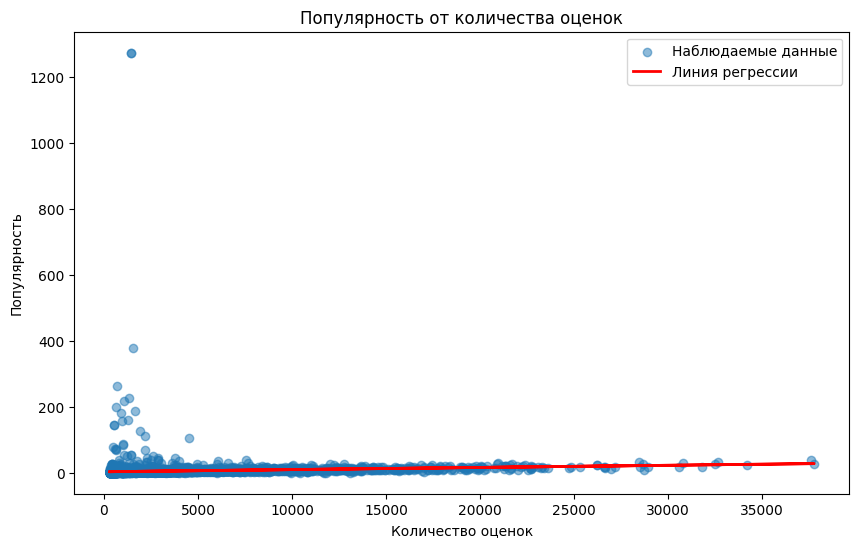

Уравнение: popularity = 2.94 + 0.0007*vote_count
R² = 0.0110


In [185]:
model_2 = LinearRegression()
X_2 = films[['vote_count']]
y_2 = films['popularity']
model_2.fit(X_2, y_2)

pred_2 = model_2.predict(X_2)

plt.figure(figsize=(10, 6))
plt.scatter(films['vote_count'], films['popularity'], alpha=0.5, label="Наблюдаемые данные")
plt.plot(films['vote_count'], pred_2, color='red', linewidth=2, label="Линия регрессии")
plt.title("Популярность от количества оценок")
plt.xlabel("Количество оценок")
plt.ylabel("Популярность")
plt.legend()
plt.show()

print(f"Уравнение: popularity = {model_2.intercept_:.2f} + {model_2.coef_[0]:.4f}*vote_count")
print(f"R² = {model_2.score(X_2, y_2):.4f}")

In [186]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = films.select_dtypes('number').drop(['vote_average'], axis=1)
y = films['vote_average']

degree = 2
poly = PolynomialFeatures(degree, include_bias=False)
X_poly = poly.fit_transform(X)

columns = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=columns)

model = LinearRegression()
model.fit(X_poly_df, y)

y_pred = model.predict(X_poly_df)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ ВСЕХ ЧИСЛОВЫХ ПЕРЕМЕННЫХ")
print(f"Коэффициенты: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R²: {model.score(X_poly_df, y):.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

ValueError: Input X contains NaN.
PolynomialFeatures does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [187]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

films_clean = films.dropna(subset=['vote_ average'])

numeric_cols = films_clean.select_dtypes('number').columns
X_cols = [col for col in numeric_cols if col != 'vote_average']

films_clean = films_clean.dropna(subset=X_cols)

X = films_clean[X_cols]
y = films_clean['vote_average']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Фактические значения vote_average')
plt.ylabel('Предсказанные значения vote_average')
plt.title(f'Предсказанные vs Фактические значения\nR² = {model.score(X_poly_df, y):.4f}')
plt.grid(True, alpha=0.3)

KeyError: ['vote_ average']

In [188]:
X_popularity = films[['popularity']]
poly_single = PolynomialFeatures(degree=2, include_bias=False)
X_poly_popularity = poly_single.fit_transform(X_popularity)

model_popularity = LinearRegression()
model_popularity.fit(X_poly_popularity, y)

y_pred_popularity = model_popularity.predict(X_poly_popularity)
mse_popularity = mean_squared_error(y, y_pred_popularity)
rmse_popularity = np.sqrt(mse_popularity)

print("\nПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ: vote_average - popularity + popularity^2")
print(f"Коэффициенты: {model_popularity.coef_}")
print(f"Intercept: {model_popularity.intercept_:.4f}")
print(f"R²: {model_popularity.score(X_poly_popularity, y):.4f}")
print(f"MSE: {mse_popularity:.4f}")
print(f"RMSE: {rmse_popularity:.4f}")


ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ: vote_average - popularity + popularity^2
Коэффициенты: [ 1.00374490e-02 -8.25747628e-06]
Intercept: 6.8280
R²: 0.0175
MSE: 0.3318
RMSE: 0.5760


In [202]:
X_vote_count = films[['vote_count']]
poly_vote = PolynomialFeatures(degree=2, include_bias=False)
X_poly_vote_count = poly_vote.fit_transform(X_vote_count)

model_vote_count = LinearRegression()
model_vote_count.fit(X_poly_vote_count, y)

y_pred_vote_count = model_vote_count.predict(X_poly_vote_count)
mse_vote_count = mean_squared_error(y, y_pred_vote_count)
rmse_vote_count = np.sqrt(mse_vote_count)

print("\nПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ: vote_average = vote_count + vote_count²")
print(f"Коэффициенты: {model_vote_count.coef_}")
print(f"Intercept: {model_vote_count.intercept_:.4f}")
print(f"R²: {model_vote_count.score(X_poly_vote_count, y):.4f}")
print(f"MSE: {mse_vote_count:.4f}")
print(f"RMSE: {rmse_vote_count:.4f}")

vote_count_sorted = np.linspace(films['vote_count'].min(), films['vote_count'].max(), 100)
vote_count_sorted_poly = poly_vote.transform(vote_count_sorted.reshape(-1, 1))
predicted_vote_count = model_vote_count.predict(vote_count_sorted_poly)

plt.figure(figsize=(10, 6))
plt.scatter(films['vote_count'], films['vote_average'], label="Наблюдаемые данные", alpha=0.7)
plt.plot(vote_count_sorted, predicted_vote_count, color='red', label="Полиномиальная регрессия", linewidth=2)
plt.title("Полиномиальная регрессия: Средняя оценка от количества оценок")
plt.xlabel("Количество оценок")
plt.ylabel("Средняя оценка")
plt.legend()
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [8560, 20058]

In [190]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_clean = chess.dropna(subset=['white_rating', 'black_rating', 'turns'])

print(f"Размер данных после очистки: {len(df_clean)}")

numeric_cols = df_clean.select_dtypes('number').columns
X_cols = [col for col in numeric_cols if col not in ['turns', 'id'] and df_clean[col].notna().all()]

X = df_clean[X_cols]
y = df_clean['turns']

print(f"Размер X: {X.shape}, Размер y: {y.shape}")

degree = 2
poly = PolynomialFeatures(degree, include_bias=False)
X_poly = poly.fit_transform(X)

columns = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=columns)

model = LinearRegression()
model.fit(X_poly_df, y)

y_pred = model.predict(X_poly_df)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ ВСЕХ ЧИСЛОВЫХ ПЕРЕМЕННЫХ")
print(f"Коэффициенты: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R²: {model.score(X_poly_df, y):.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Размер данных после очистки: 20058
Размер X: (20058, 6), Размер y: (20058,)
ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ ВСЕХ ЧИСЛОВЫХ ПЕРЕМЕННЫХ
Коэффициенты: [-3.43227217e-21 -3.43091145e-21 -4.03994236e-28  2.57326434e-27
  6.02909326e-27 -5.54812654e-28 -3.47375539e-15  6.94602104e-15
  2.56821983e-15  3.59922555e-15  8.92978793e-15 -1.03100572e-15
 -3.47226563e-15  2.56826209e-15  3.59927607e-15  8.92979440e-15
 -1.03101398e-15  1.14047572e-23  1.62180405e-23  1.02426522e-23
 -4.81328334e-24  1.27391614e-23  1.02463968e-23  3.47887908e-24
  8.02928610e-26 -3.74457018e-27 -8.29216242e-24]
Intercept: -11.8892
R²: 0.0503
MSE: 1070.2577
RMSE: 32.7148


In [200]:
X_white_rating = df_clean[['white_rating']]
y_white = df_clean['turns']

print(f"Размер X_white_rating: {X_white_rating.shape}, Размер y_white: {y_white.shape}")

poly_single = PolynomialFeatures(degree=2, include_bias=False)
X_poly_white = poly_single.fit_transform(X_white_rating)

model_white = LinearRegression()
model_white.fit(X_poly_white, y_white)

y_pred_white = model_white.predict(X_poly_white)
mse_white = mean_squared_error(y_white, y_pred_white)
rmse_white = np.sqrt(mse_white)

print("\nПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ: turns = white_rating + white_rating²")
print(f"Коэффициенты: {model_white.coef_}")
print(f"Intercept: {model_white.intercept_:.4f}")
print(f"R²: {model_white.score(X_poly_white, y_white):.4f}")
print(f"MSE: {mse_white:.4f}")
print(f"RMSE: {rmse_white:.4f}")

Размер X_white_rating: (20058, 1), Размер y_white: (20058,)

ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ: turns = white_rating + white_rating²
Коэффициенты: [ 7.08395234e-02 -1.70333432e-05]
Intercept: -7.7718
R²: 0.0204
MSE: 1103.9510
RMSE: 33.2258


In [192]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X = df_clean.select_dtypes('number').drop(['turns'], axis=1)
y = df_clean['turns']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("МНОЖЕСТВЕННАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ ВСЕХ ЧИСЛОВЫХ ПЕРЕМЕННЫХ")
print(f"Коэффициенты: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R²: {model.score(X, y):.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print("Признаки:", X.columns.tolist())

МНОЖЕСТВЕННАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ ВСЕХ ЧИСЛОВЫХ ПЕРЕМЕННЫХ
Коэффициенты: [-4.20617852e-07  4.20691613e-07  7.96191040e-03  1.11046103e-02
  7.26545933e-02 -3.14269989e-03]
Intercept: -80.0146
R²: 0.0344
MSE: 1088.1109
RMSE: 32.9865
Признаки: ['created_at', 'last_move_at', 'white_rating', 'black_rating', 'opening_ply', 'rating_diff']


In [201]:
X_simple = df_clean[['white_rating']]
y_simple = df_clean['turns']

model_simple = LinearRegression()
model_simple.fit(X_simple, y_simple)

y_pred_simple = model_simple.predict(X_simple)
mse_simple = mean_squared_error(y_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print("\nПРОСТАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ: turns и white_rating")

print(f"Коэффициент: {model_simple.coef_[0]:.4f}")
print(f"Intercept: {model_simple.intercept_:.4f}")
print(f"R²: {model_simple.score(X_simple, y_simple):.4f}")
print(f"MSE: {mse_simple:.4f}")
print(f"RMSE: {rmse_simple:.4f}")


ПРОСТАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ: turns и white_rating
Коэффициент: 0.0150
Intercept: 36.5874
R²: 0.0168
MSE: 1107.9553
RMSE: 33.2860
